In [1]:
import sys
import os

# Add the parent directory to the Python path
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
import matplotlib.patches as patches
import torch
import copy
import sys
sys.path.append("/Users/LOCCO_Louise/Documents/Git/code_amaury")
from simu_PSF_polarMFM import *
from extract_experimental_psf import *
from tqdm import tqdm
import time
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

In [2]:
if torch.cuda.is_available():
    device = torch.device('cuda')
    print("Using GPU")
else:   
    device = torch.device('cpu')
    print("Using CPU")

Using GPU


In [3]:
d = np.array([3,3,3])
d = np.array([np.mean(d)-0.350, np.mean(d), np.mean(d)+0.350])
QE = 0.92
EM = 100
sensitivity = 15.4

In [4]:
Nframe=15

In [5]:
raw = np.zeros((Nframe,6,214,129))

In [6]:
path_info = 'C:\\Users\\Amaury\\Desktop\\cell005midS\\cell005_polar_1_results_fr1to60000_method=Propagationmatrix_box-method=Fixed_box5.csv'

In [14]:
def extract_frames(frame_0, N_frame):
    error_indices = []
    for i in range(N_frame):
        number = str(frame_0 + i).zfill(5)
        print(number)
        path_data = 'C:\\Users\\Amaury\\Desktop\\cell005midS\\cell005_polar_1_reco_concat\\cell005_polar_1_'+number+'.tif'
        raw_ = extract_raw(path_data)
        if raw_ is None:
            error_indices.append(i)
            continue
        else:
            raw[i] = raw_
        del(raw_)
    return raw, error_indices

def extract_positions(frame_0, N_frame, error_indices):
    index_frame = []
    x, y, z, rho, delta = [], [], [], [], []
    ind = 0
    for i in range(N_frame):
        if i not in error_indices:
            x__, y__, z__, rho__, delta__ = position_from_data(data, frame_0+i)
            x = np.concatenate((x, x__))
            y = np.concatenate((y, y__))
            z = np.concatenate((z, z__))
            rho = np.concatenate((rho, rho__))
            delta = np.concatenate((delta, delta__))
            for k in range(len(x__)):
                index_frame.append(ind)
        ind+=1
    index_frame=np.array(index_frame)
    return x, y, z, rho, delta, index_frame

def limit(x, lim, slope, upper=True):
    '''
    if upper:
       return torch.sum(torch.tensor(1/(1+torch.exp(-slope*(x-lim))), requires_grad=True, device=device))
    else:
        return torch.sum(torch.tensor(1/(1+torch.exp(slope*(x-lim))), requires_grad=True, device=device))
    '''
    if upper:
        return torch.sum(torch.exp((x-lim)*slope))
    else:
        return torch.sum(torch.exp(-1*(x-lim)*slope))
    
def loss_pos(xp, yp, zp, rho, eta, delta, N_photons, data, second_plane, background, sigma, dim_simu, plot=False):
    u, v, M_ = compute_M(xp=xp, yp=yp, zp=zp, d=d_, x=xx, y=yy, th1=th1, phi=phi, Ex0=Ex0, Ex1=Ex1, Ex2=Ex2
                    , Ey0=Ey0, Ey1=Ey1, Ey2=Ey2, r=r, r_cut=r_cut, k=k_, f_o=f_o, phase_maskx=phase_mask, phase_masky=phase_mask, zernike_base=zernike_base, zernike_coefs_x=zernike_coefs_x, zernike_coefs_y=zernike_coefs_x,
                        second_plane=second_plane, polar_projections=polar_projections, N=N,
                    l_pixel=l_pixel, NA=NA, mag=mag, lambd=lambd, f_tube=f_tube, MAG=MAG, device=device, polar_offset=0., polar_offset2=0.)
    dim_data = 6
    h = PSF(rho=rho, eta=eta, delta=delta, M=M_, N_photons=N_photons)[:,:,:,dim_simu-dim_data:dim_simu+dim_data+1,dim_simu-dim_data:dim_simu+dim_data+1]
    loss = torch.sum(torch.add(h, -(data+sigma**2)*torch.log(h+background+sigma**2)))
    #loss = torch.sum(torch.pow(torch.sum(torch.add(h, -data), dim=(2,)), 2)) 
    x_bound = limit(xp, 5*0.12, 100, upper=True) + limit(xp, -5*0.12, 100, upper=False)
    y_bound = limit(yp, 5*0.12, 100, upper=True) + limit(yp, -5*0.12, 100, upper=False)
    z_bound = limit(zp, 5., 100, upper=True) + limit(zp, 0., 100, upper=False)
    N_bound = torch.sum((N_photons - (torch.sum(data, dim=(1,2,3,4)) - background*len(data[0].flatten())) )**2)
    if plot:
        fig, ax = plt.subplots(3,2)
        for aa in range(3):
            for bb in range(2):
                ax[aa,bb].imshow(data[1,aa,bb].cpu().numpy(), cmap='gray')
        plt.show()
        fig, ax = plt.subplots(3,2)
        for aa in range(3):
            for bb in range(2):
                ax[aa,bb].imshow(h[1,aa,bb].detach().cpu().numpy(), cmap='gray')
        plt.show()
    return loss +x_bound+y_bound+z_bound+N_bound

def loss_angle(M_, rho, eta, delta, N_photons, data, background, sigma, dim_simu):
    dim_data = 6
    h = PSF(rho=rho, eta=eta, delta=delta, M=M_, N_photons=N_photons)[:,:,:,dim_simu-dim_data:dim_simu+dim_data+1,dim_simu-dim_data:dim_simu+dim_data+1]

    loss = torch.sum(torch.add(h, -(data+sigma**2)*torch.log(h+background+sigma**2)))
    #loss = torch.sum(torch.pow(torch.sum(torch.add(h, -data), dim=(2,)), 2)) 
    delta_bound = limit(delta, 180, 100, upper=True) + limit(delta, 1, 100, upper=False)
    N_bound = torch.sum((N_photons - (torch.sum(data, dim=(1,2,3,4)) - background*len(data[0].flatten())) )**2)
    return loss + 1000.*(delta_bound) + N_bound #+ 100000*torch.sum(h**2)

def loss_angle_with_M(polar_proj, polar_proj2, rho, eta, delta, N_photons, data, background, sigma, dim_simu):
    dim_data = 6
    u, v, M_ = compute_M(xp=x_found, yp=y_found, zp=z_found, d=d_, x=xx, y=yy, th1=th1, phi=phi, Ex0=Ex0, Ex1=Ex1, Ex2=Ex2
                    , Ey0=Ey0, Ey1=Ey1, Ey2=Ey2, r=r, r_cut=r_cut, k=k_, f_o=f_o, phase_masky=phase_mask, phase_maskx=phase_mask, zernike_base=zernike_base, zernike_coefs_x=zernike_coefs_x, zernike_coefs_y=zernike_coefs_x,
                        second_plane=second_plane, polar_projections=polar_projections, N=N,
                    l_pixel=l_pixel, NA=NA, mag=mag, lambd=lambd, f_tube=f_tube, MAG=MAG, device=device, polar_offset=polar_proj, polar_offset2=polar_proj2)
    h = PSF(rho=rho, eta=eta, delta=delta, M=M_, N_photons=N_photons)[:,:,:,dim_simu-dim_data:dim_simu+dim_data+1,dim_simu-dim_data:dim_simu+dim_data+1]
    
    loss = torch.sum(torch.add(h, -(data+sigma**2)*torch.log(h+background+sigma**2)))
    #loss = torch.sum(torch.pow(torch.sum(torch.add(h, -data), dim=(2,)), 2)) 
    delta_bound = limit(delta, 180, 100, upper=True) + limit(delta, 1, 100, upper=False)
    N_bound = torch.sum((N_photons - (torch.sum(data, dim=(1,2,3,4)) - background*len(data[0].flatten())) )**2)
    return loss + 1000.*(delta_bound) + N_bound #+ 100000*torch.sum(h**2)

def score_eval(M_, rho, eta, delta, N_photons, data, background, sigma, dim_simu):
    dim_data = 6
    h = PSF(rho=rho, eta=eta, delta=delta, M=M_, N_photons=N_photons)[:,:,:,dim_simu-dim_data:dim_simu+dim_data+1,dim_simu-dim_data:dim_simu+dim_data+1]
    score = torch.sum(torch.add(h, -(data+sigma**2)*torch.log(h+background+sigma**2)), dim=(1,2,3,4))
    return score.numpy() 

In [15]:
data = pos_from_csv(path_info)

In [16]:
N_batch = 1

In [17]:
batch_offset = 0

In [18]:
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

00001
00002
00003
00004
00005
00006
00007
00008
00009
00010
00011
00012
00013
00014
00015


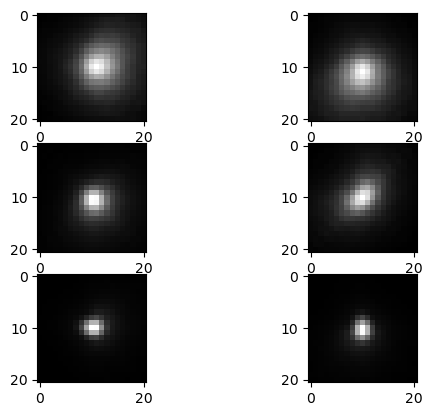

  0%|          | 0/100 [00:00<?, ?it/s]

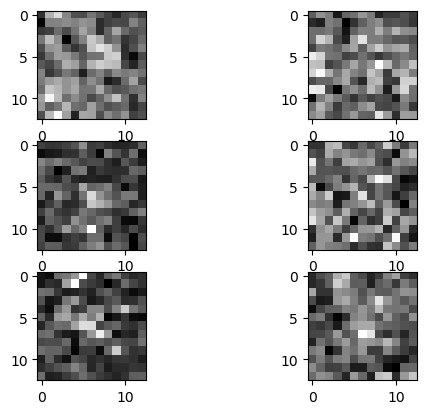

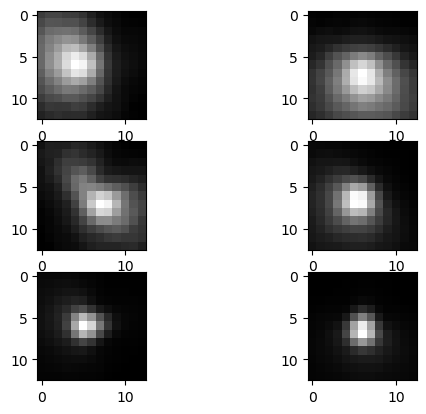

  1%|          | 1/100 [00:00<01:20,  1.23it/s]

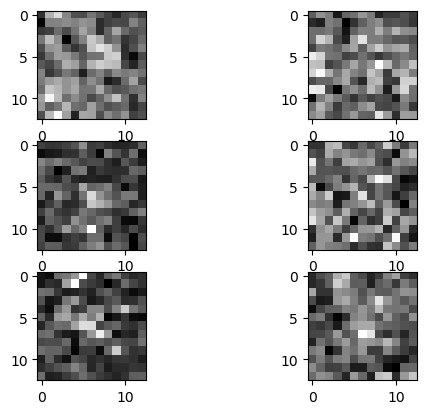

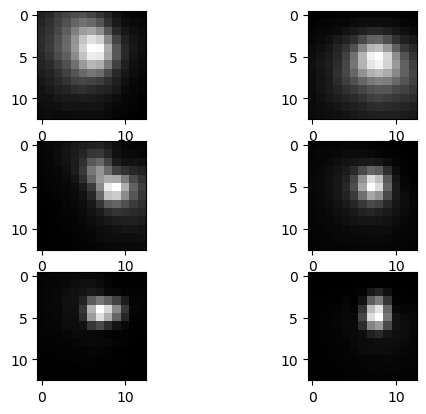

  2%|▏         | 2/100 [00:01<01:17,  1.26it/s]

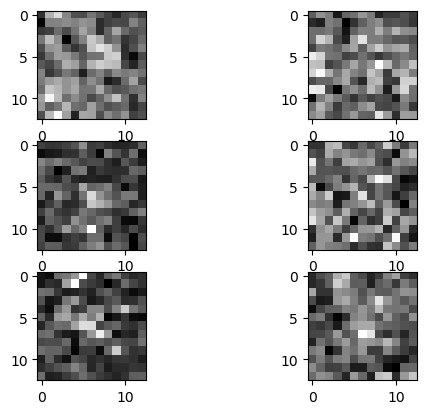

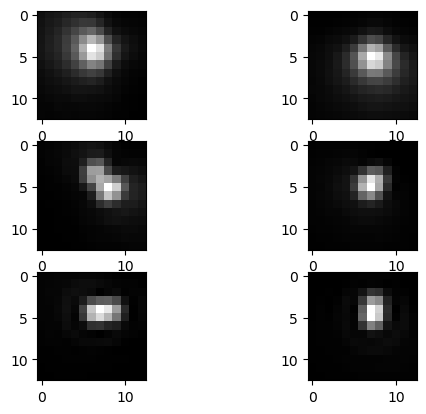

  3%|▎         | 3/100 [00:02<01:16,  1.27it/s]

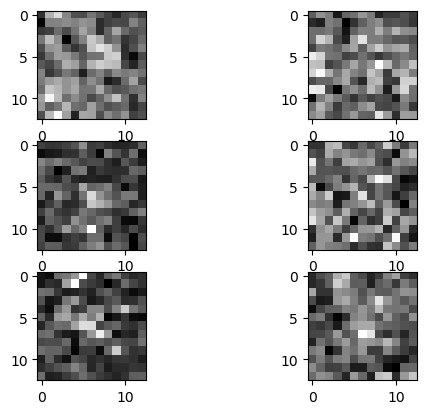

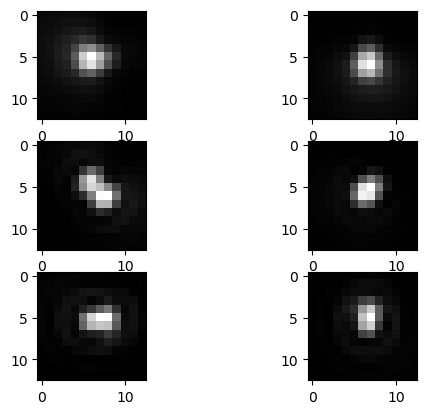

  4%|▍         | 4/100 [00:03<01:15,  1.28it/s]

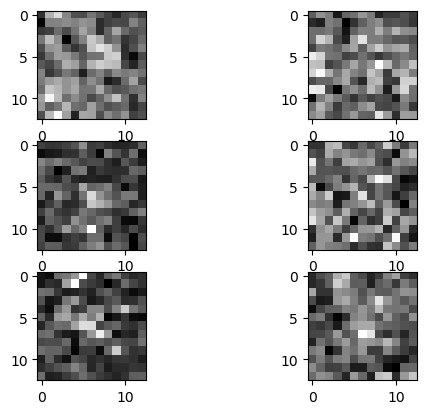

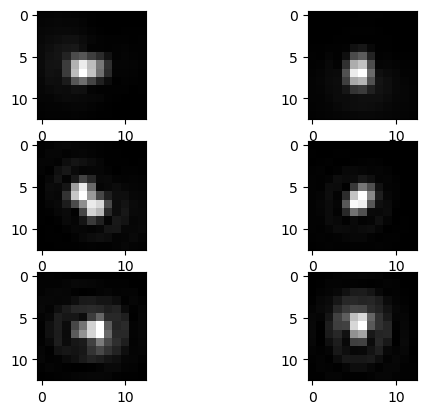

  5%|▌         | 5/100 [00:03<01:16,  1.25it/s]

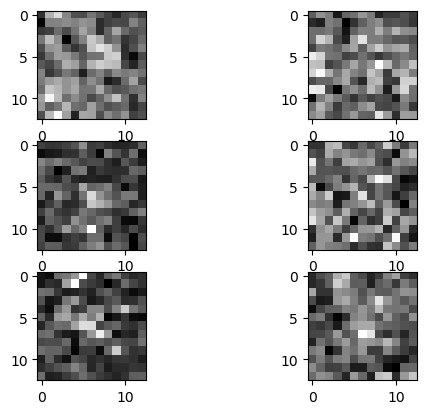

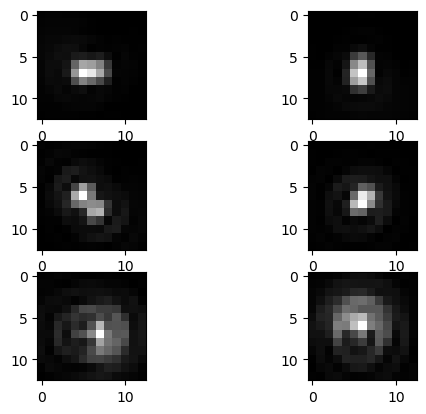

  6%|▌         | 6/100 [00:04<01:14,  1.27it/s]

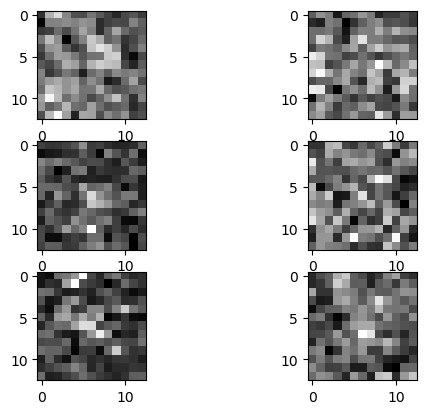

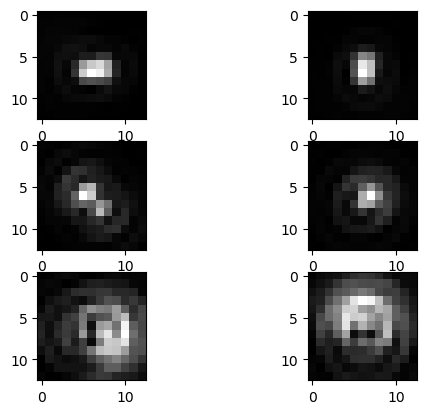

  7%|▋         | 7/100 [00:05<01:13,  1.27it/s]

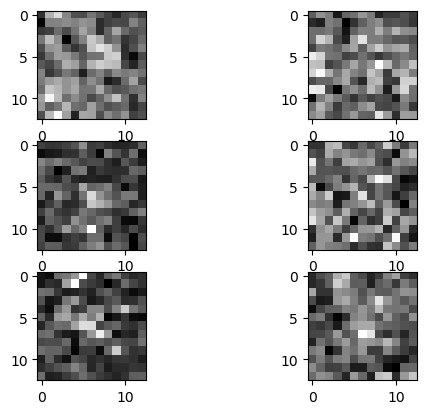

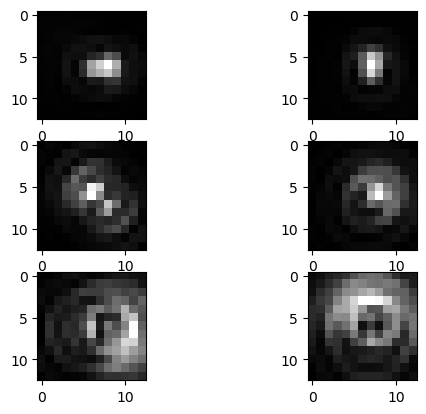

  8%|▊         | 8/100 [00:06<01:16,  1.21it/s]

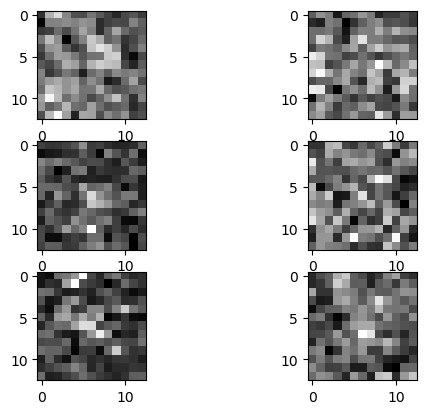

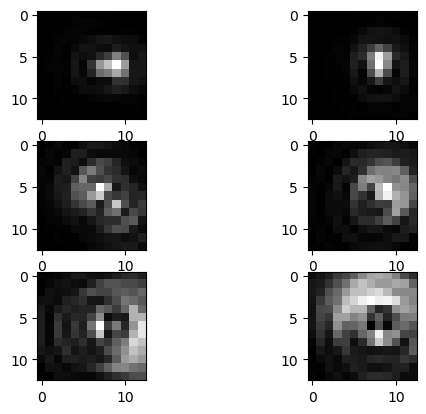

  9%|▉         | 9/100 [00:07<01:14,  1.23it/s]

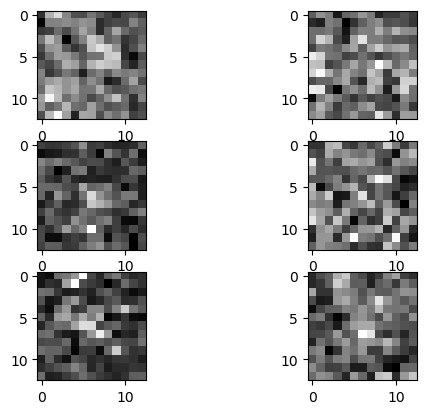

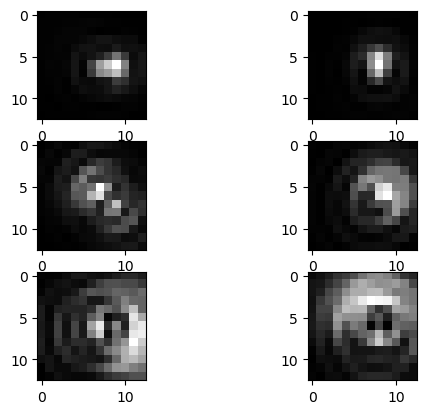

 10%|█         | 10/100 [00:07<01:11,  1.25it/s]

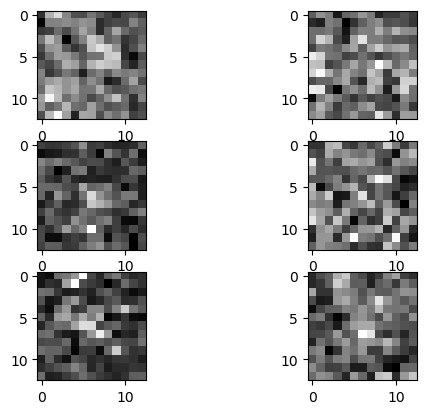

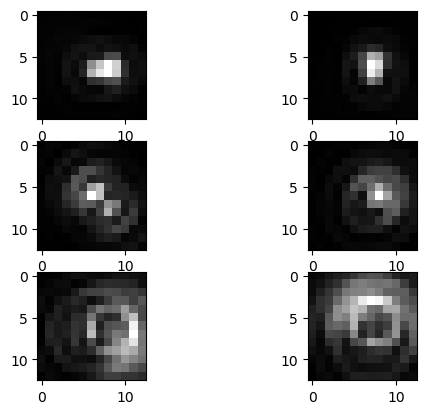

 11%|█         | 11/100 [00:08<01:15,  1.19it/s]

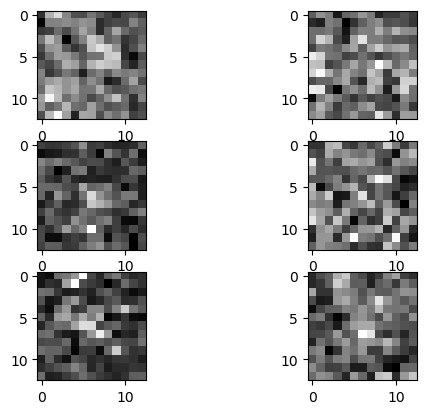

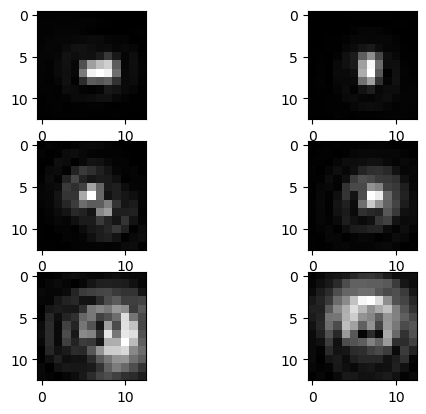

 12%|█▏        | 12/100 [00:09<01:12,  1.21it/s]

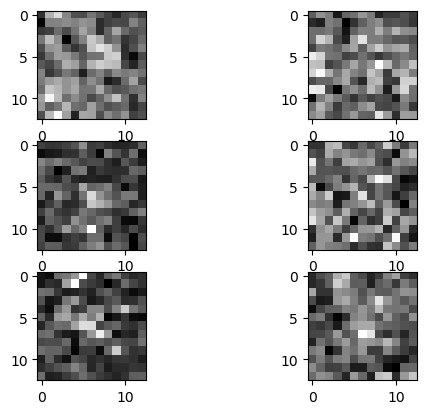

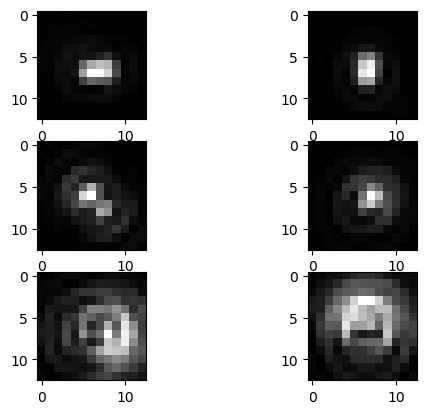

 13%|█▎        | 13/100 [00:10<01:10,  1.24it/s]

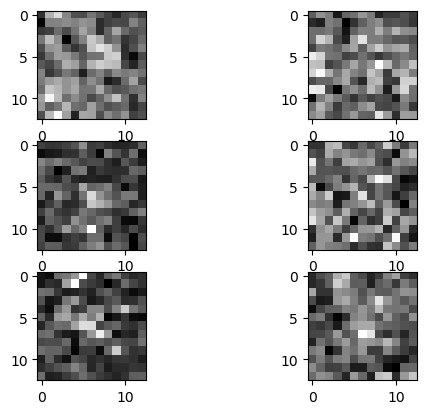

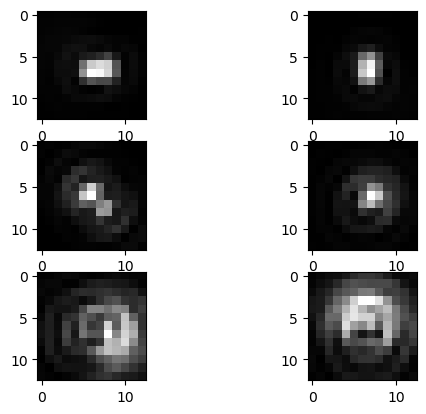

 14%|█▍        | 14/100 [00:11<01:10,  1.22it/s]

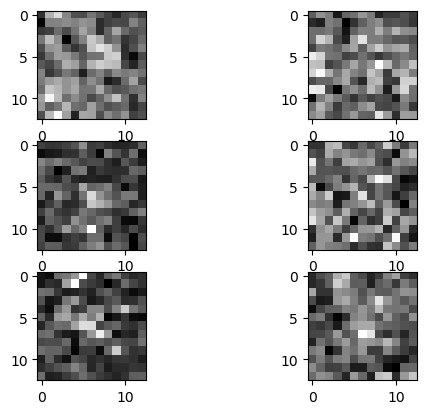

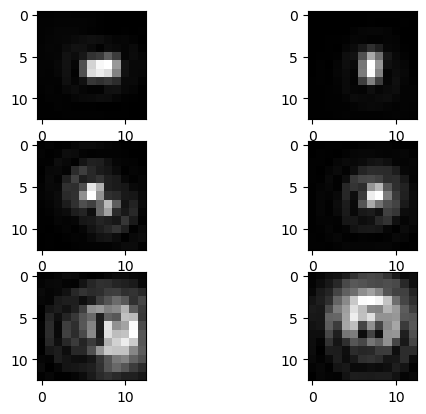

 15%|█▌        | 15/100 [00:12<01:15,  1.12it/s]

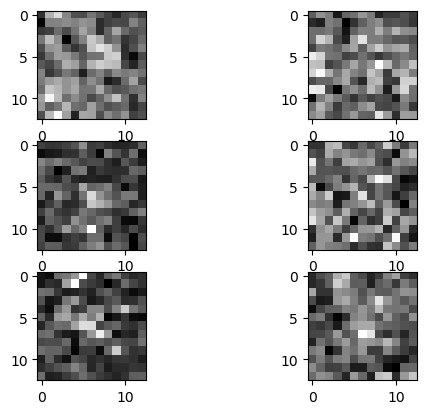

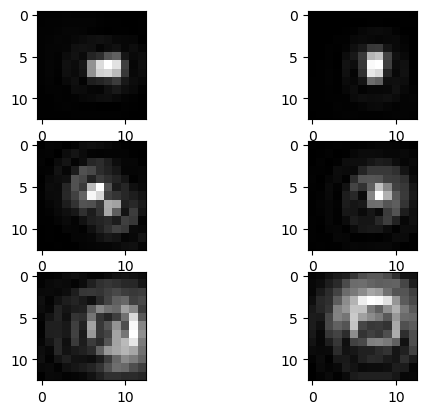

 16%|█▌        | 16/100 [00:13<01:14,  1.12it/s]

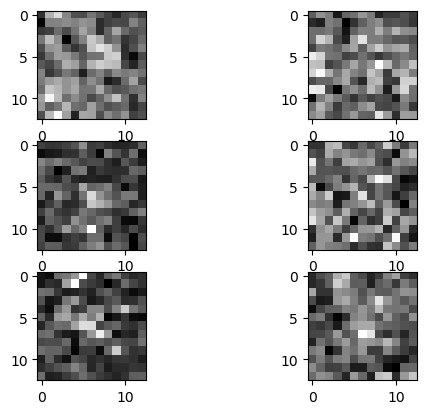

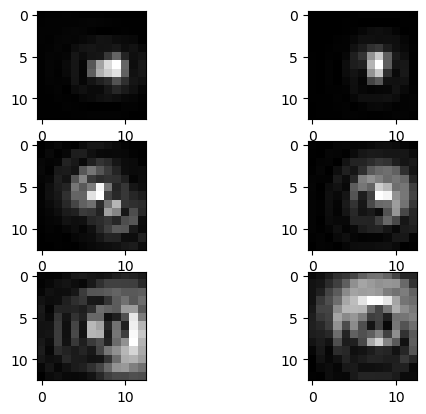

 17%|█▋        | 17/100 [00:14<01:13,  1.13it/s]

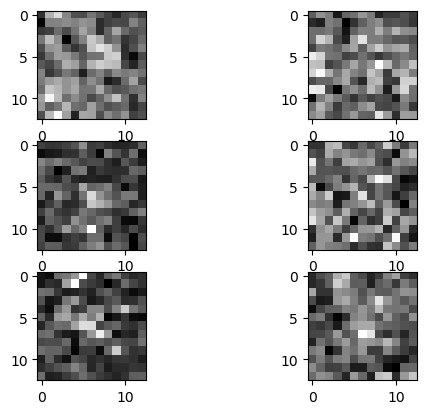

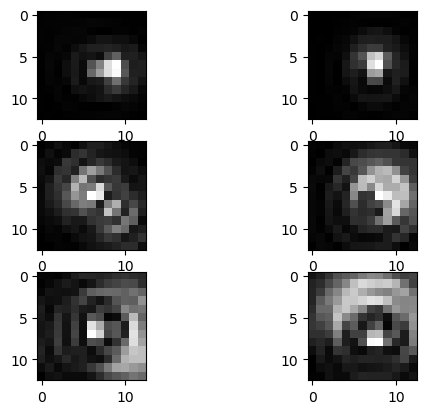

 18%|█▊        | 18/100 [00:14<01:10,  1.16it/s]

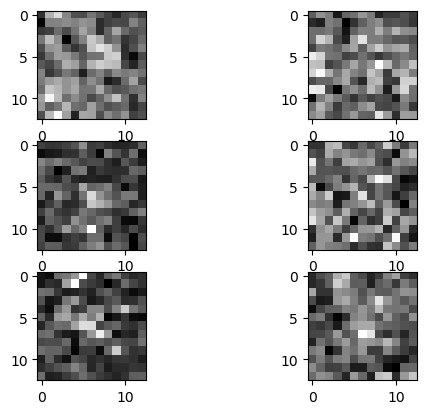

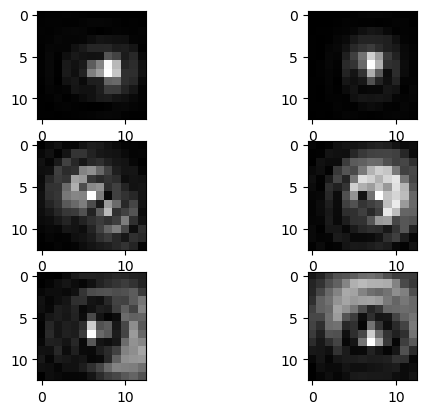

 19%|█▉        | 19/100 [00:15<01:09,  1.17it/s]

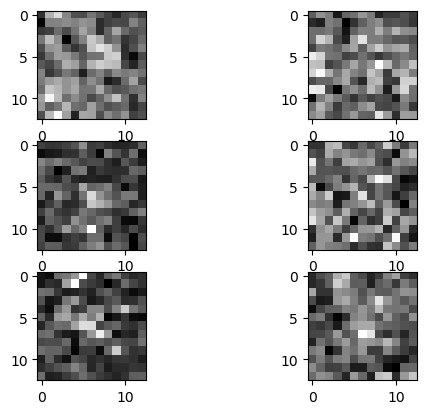

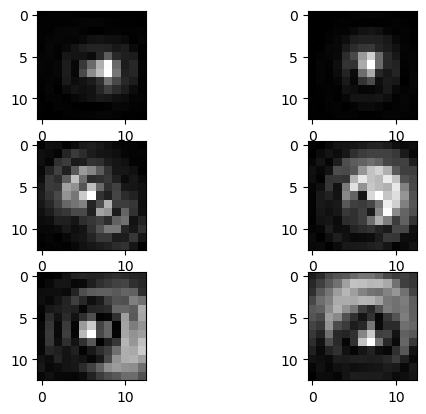

 20%|██        | 20/100 [00:16<01:06,  1.20it/s]

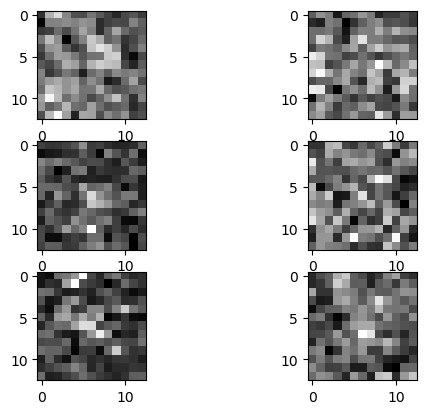

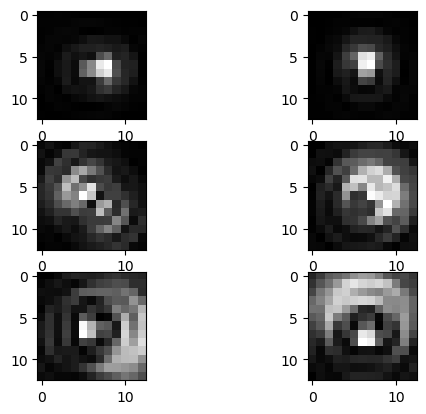

 21%|██        | 21/100 [00:17<01:04,  1.23it/s]

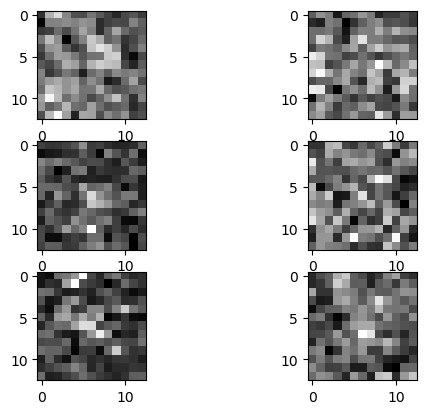

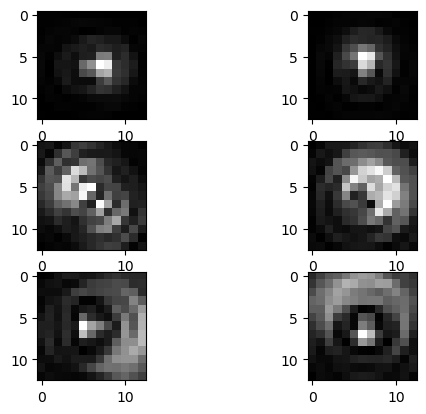

 22%|██▏       | 22/100 [00:18<01:06,  1.18it/s]

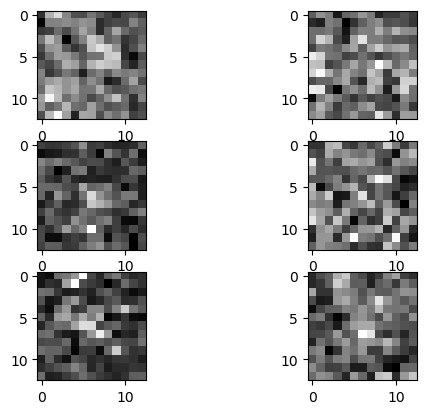

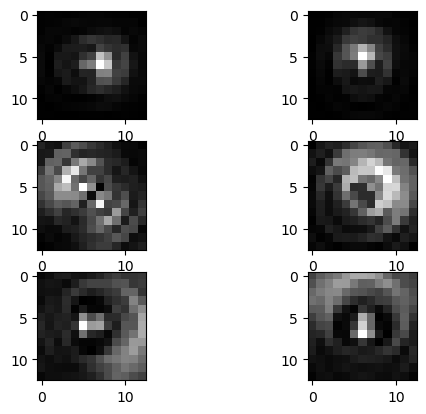

 23%|██▎       | 23/100 [00:19<01:03,  1.21it/s]

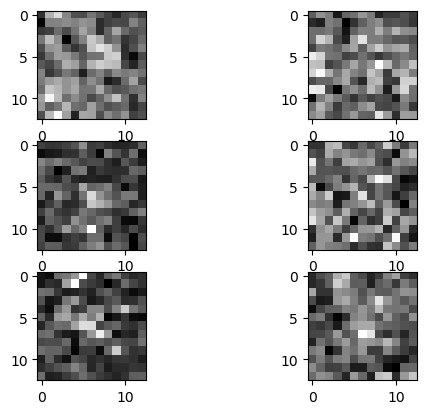

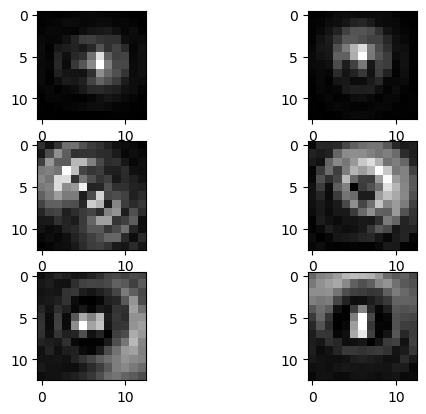

 24%|██▍       | 24/100 [00:19<01:01,  1.24it/s]

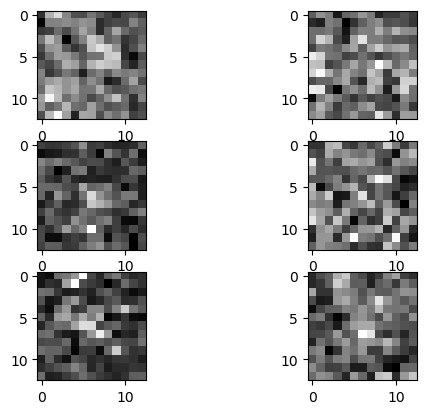

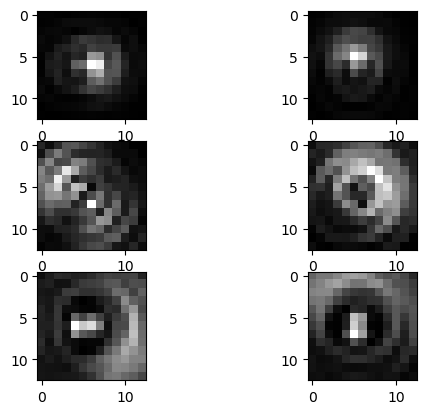

 25%|██▌       | 25/100 [00:20<00:59,  1.25it/s]

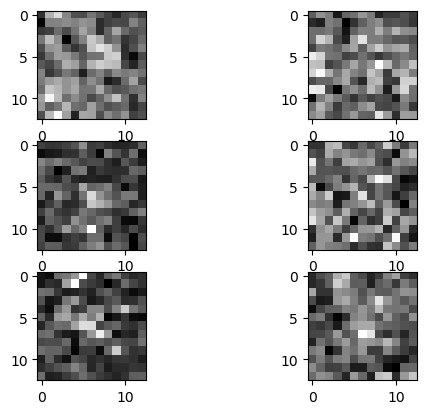

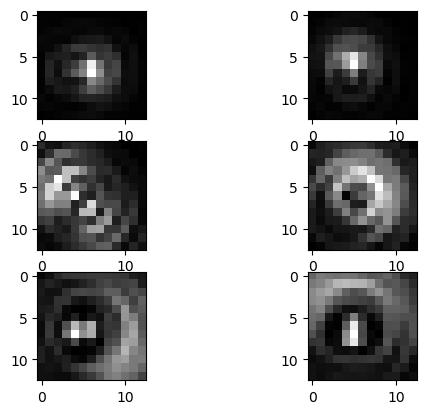

 26%|██▌       | 26/100 [00:21<01:00,  1.23it/s]

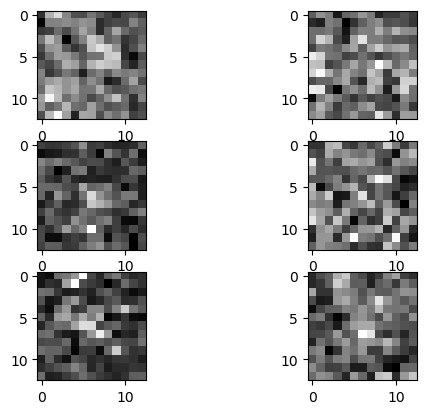

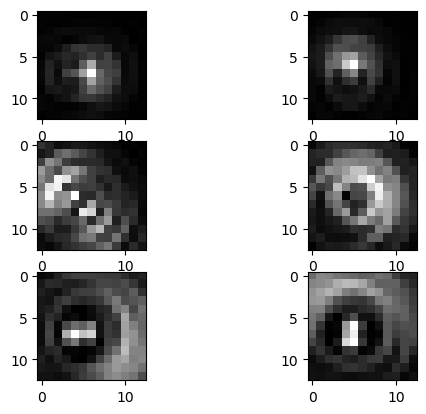

 27%|██▋       | 27/100 [00:22<00:58,  1.25it/s]

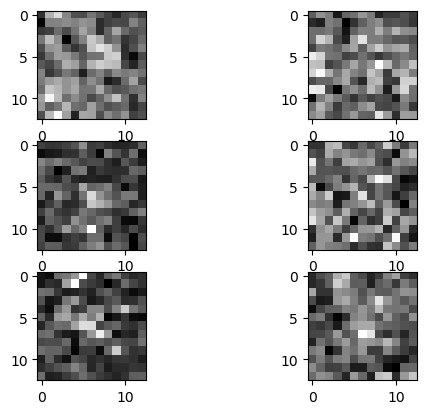

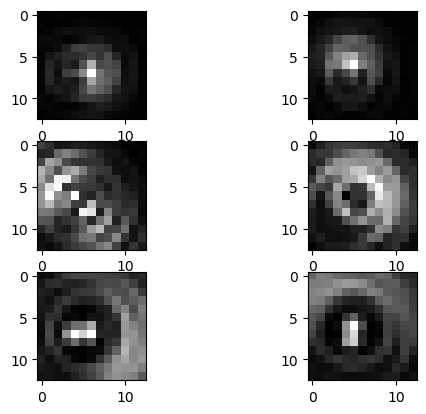

 28%|██▊       | 28/100 [00:22<00:56,  1.27it/s]

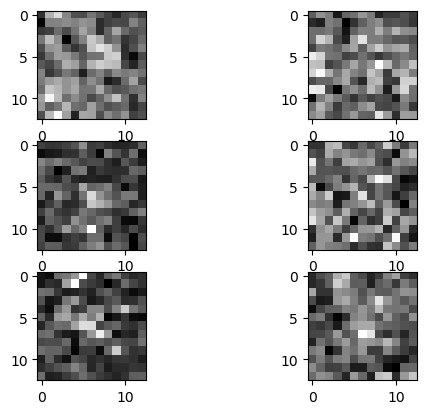

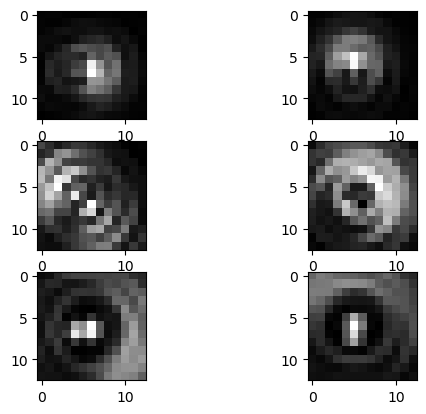

 29%|██▉       | 29/100 [00:23<00:59,  1.19it/s]

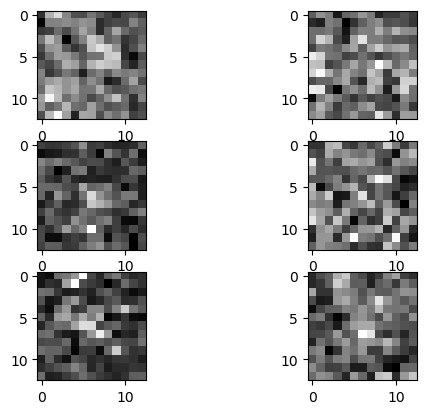

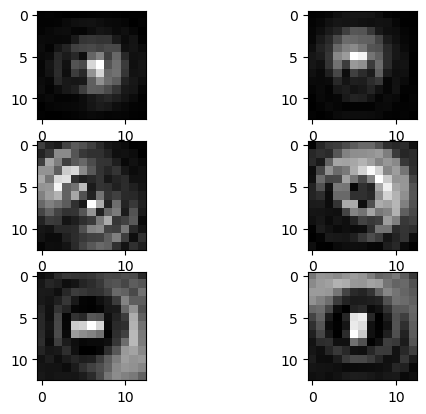

 30%|███       | 30/100 [00:24<00:56,  1.23it/s]

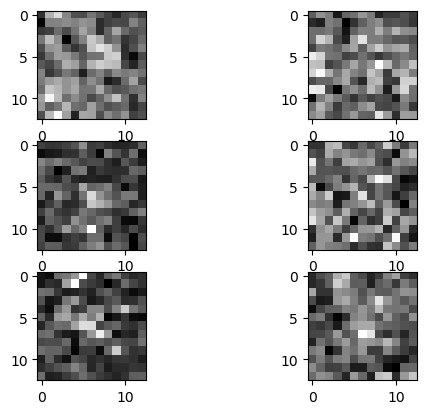

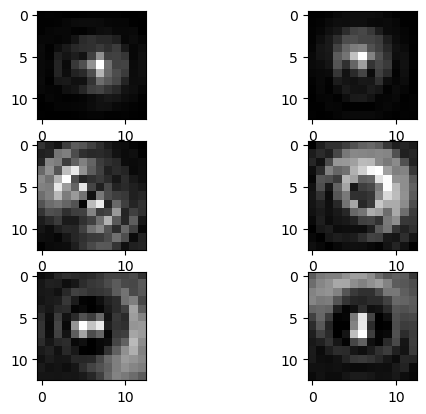

 31%|███       | 31/100 [00:25<00:55,  1.25it/s]

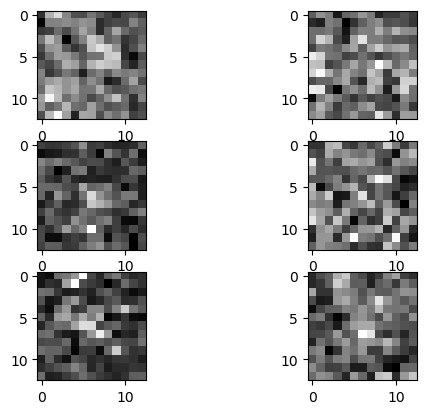

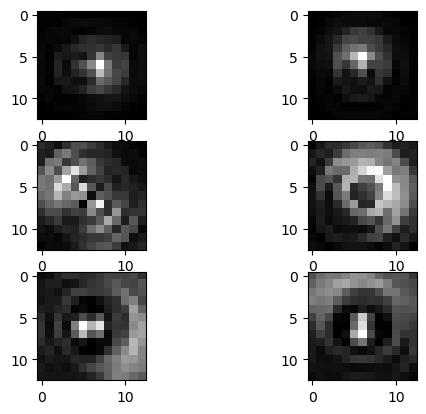

 32%|███▏      | 32/100 [00:26<00:57,  1.19it/s]

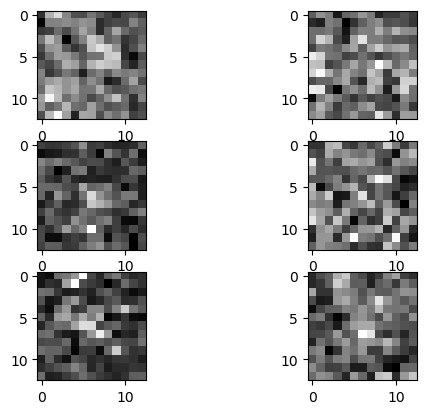

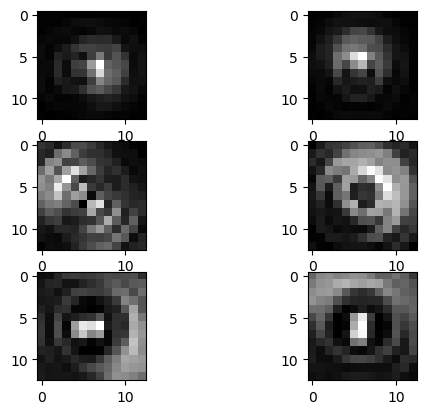

 33%|███▎      | 33/100 [00:27<00:56,  1.20it/s]

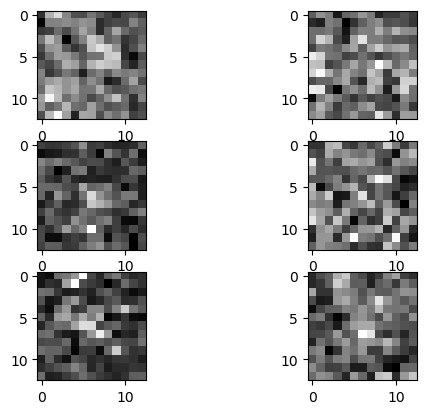

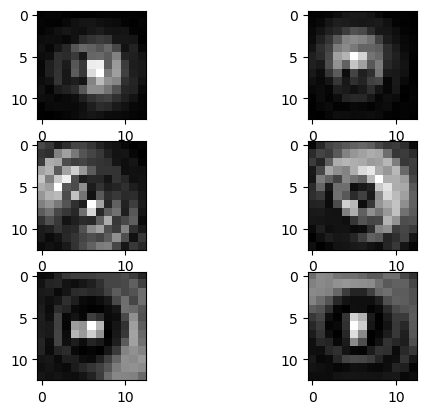

 34%|███▍      | 34/100 [00:28<00:55,  1.19it/s]

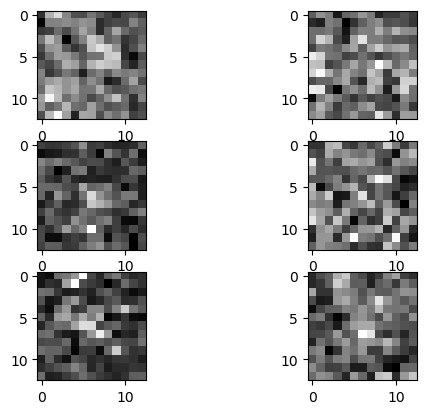

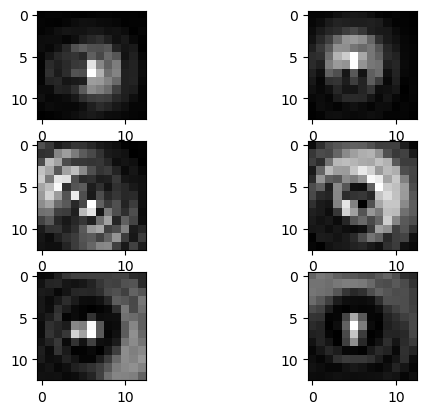

 35%|███▌      | 35/100 [00:28<00:54,  1.18it/s]

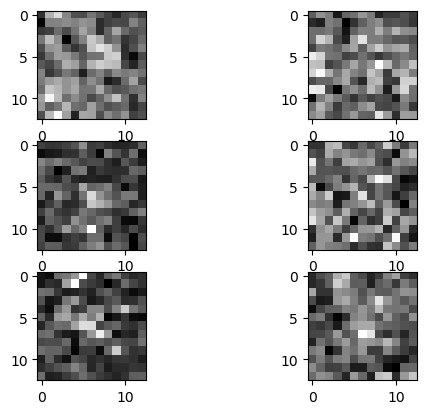

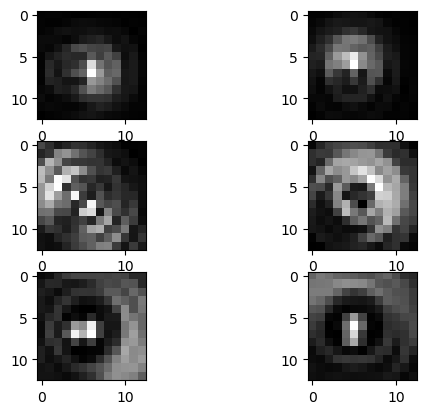

 36%|███▌      | 36/100 [00:30<00:58,  1.09it/s]

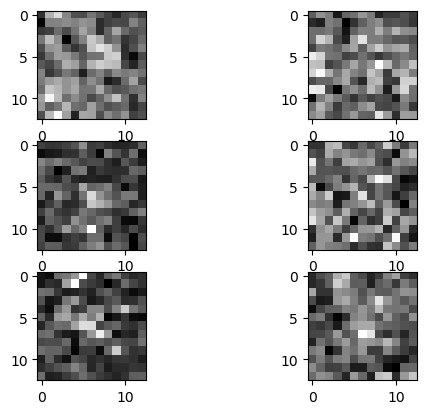

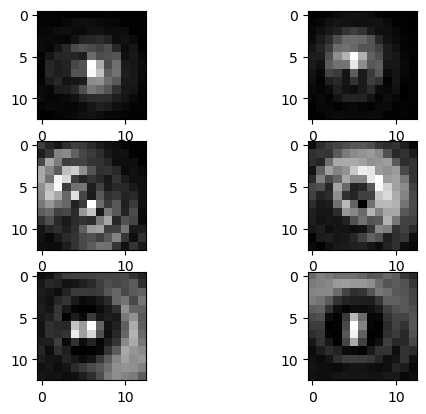

 37%|███▋      | 37/100 [00:30<00:56,  1.12it/s]

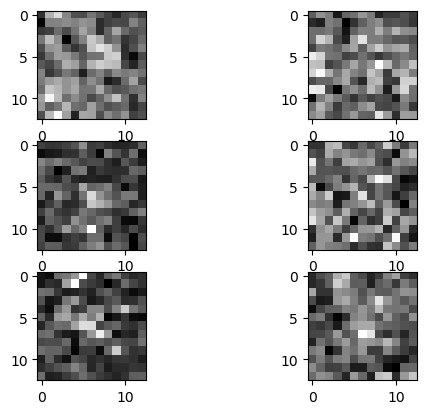

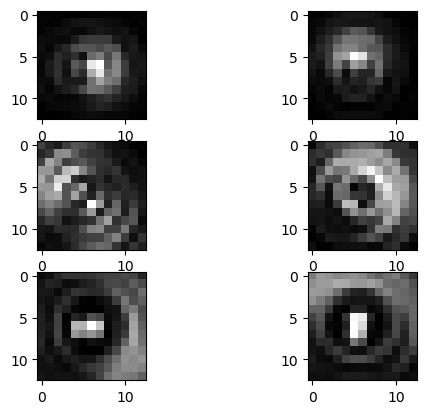

 38%|███▊      | 38/100 [00:31<00:52,  1.17it/s]

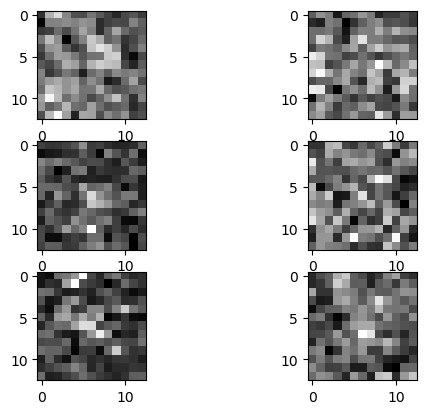

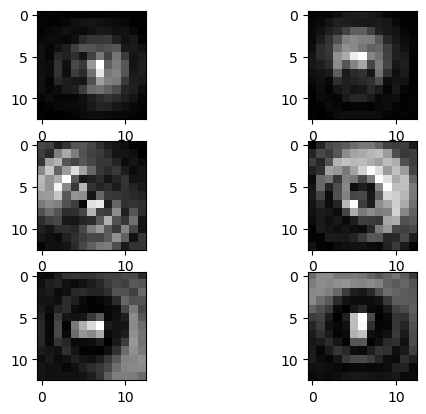

 39%|███▉      | 39/100 [00:32<00:50,  1.21it/s]

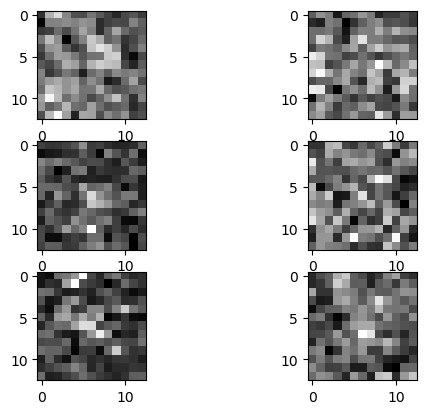

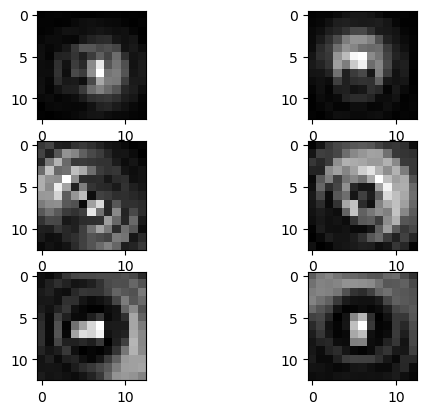

 40%|████      | 40/100 [00:33<00:49,  1.21it/s]

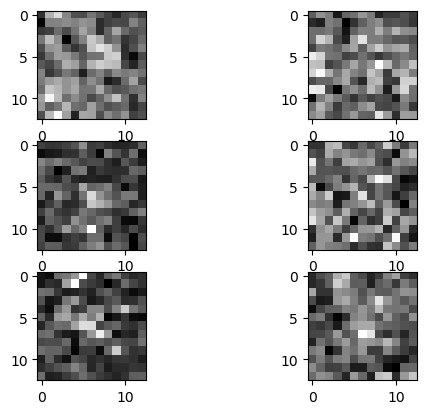

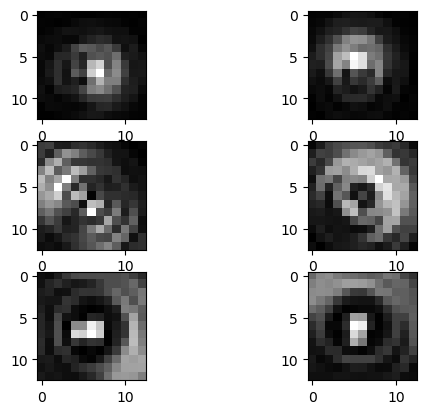

 41%|████      | 41/100 [00:33<00:47,  1.23it/s]

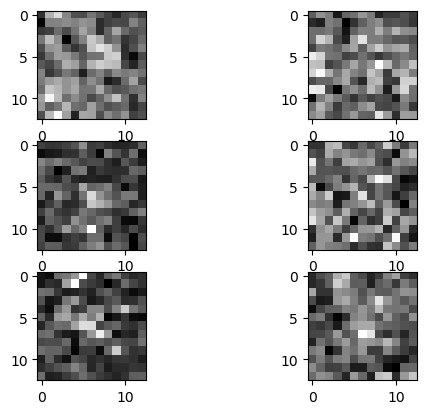

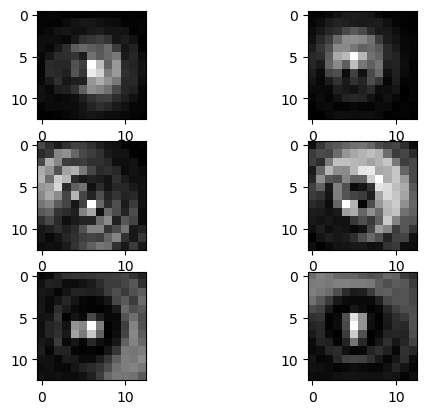

 42%|████▏     | 42/100 [00:34<00:46,  1.26it/s]

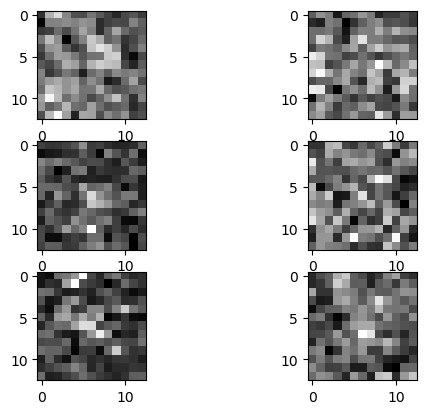

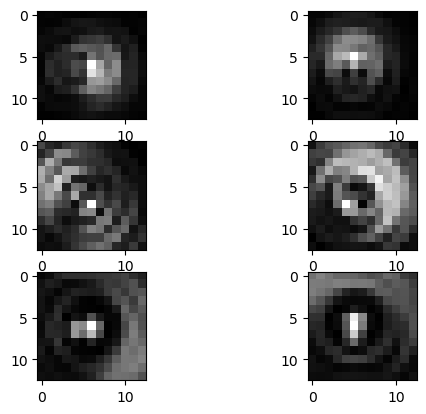

 43%|████▎     | 43/100 [00:35<00:47,  1.19it/s]

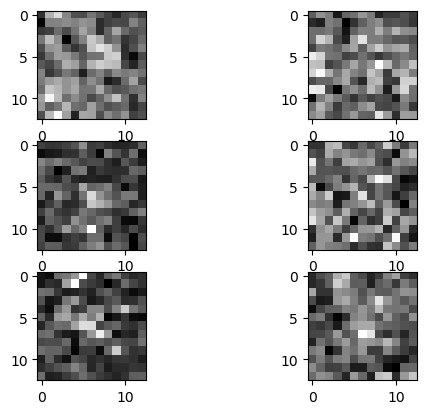

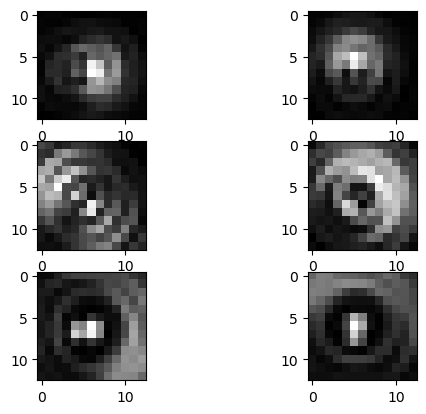

 44%|████▍     | 44/100 [00:36<00:45,  1.23it/s]

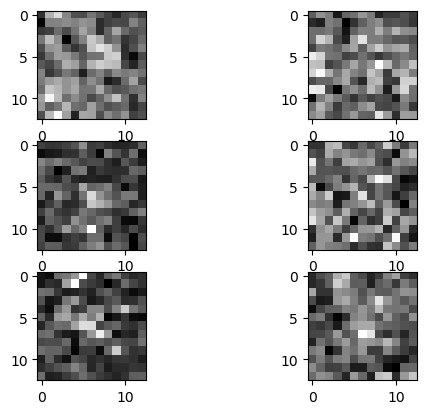

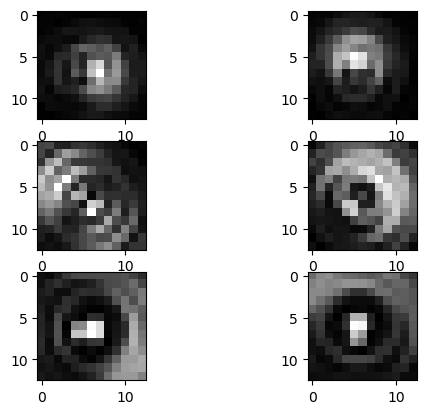

 45%|████▌     | 45/100 [00:37<00:43,  1.25it/s]

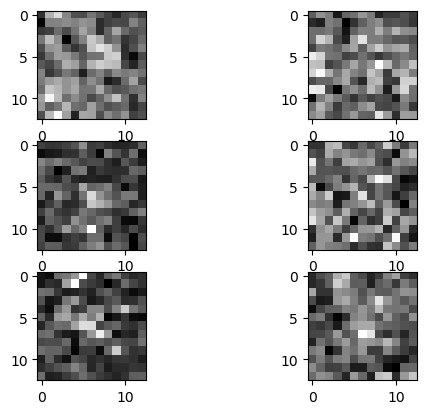

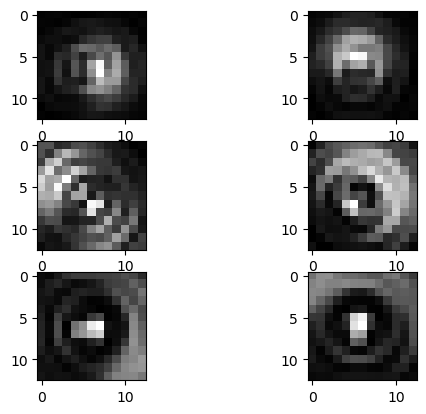

 46%|████▌     | 46/100 [00:37<00:42,  1.26it/s]

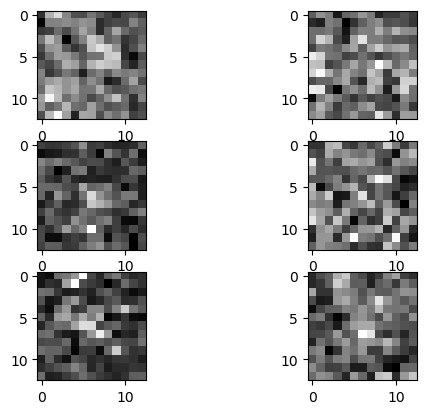

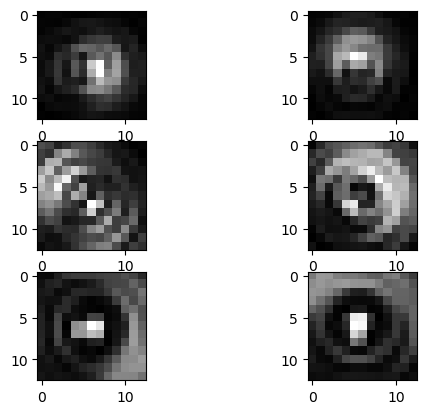

 47%|████▋     | 47/100 [00:38<00:44,  1.19it/s]

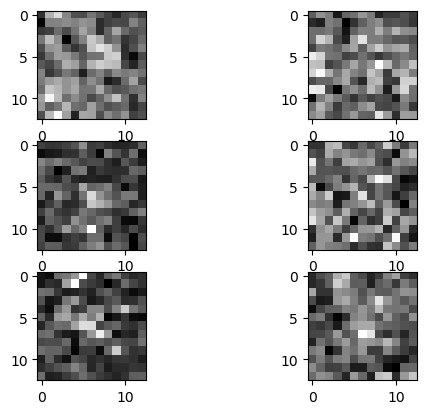

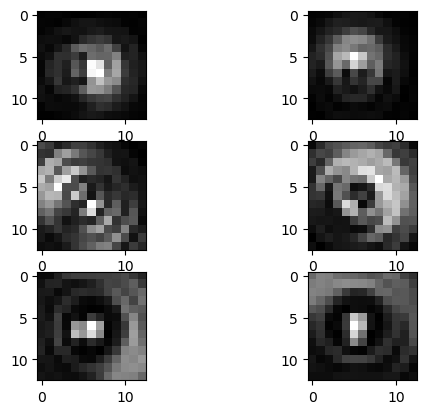

 48%|████▊     | 48/100 [00:39<00:42,  1.22it/s]

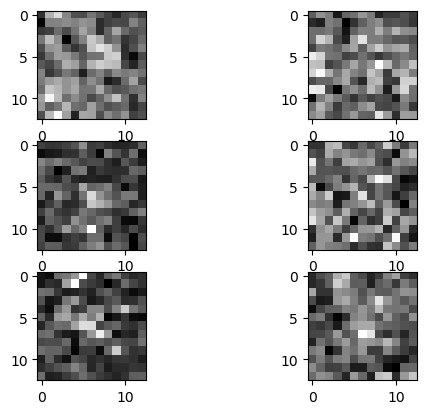

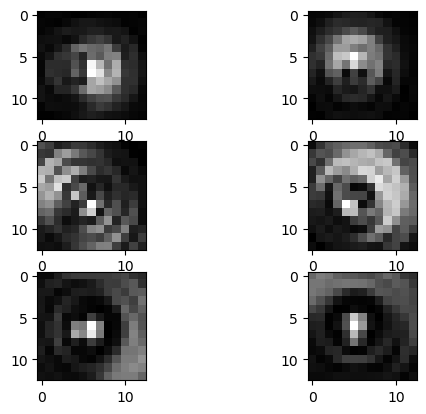

 49%|████▉     | 49/100 [00:40<00:40,  1.26it/s]

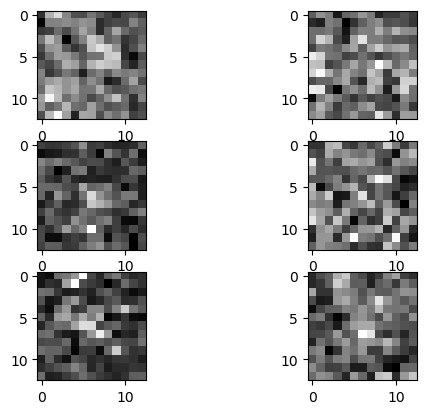

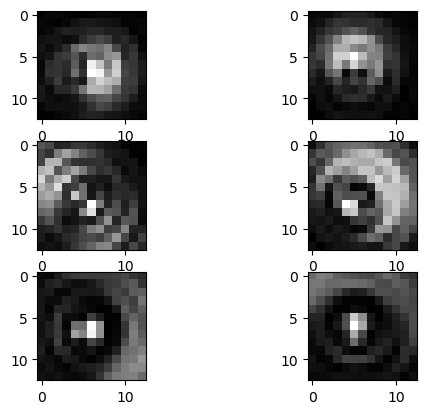

 50%|█████     | 50/100 [00:41<00:41,  1.19it/s]

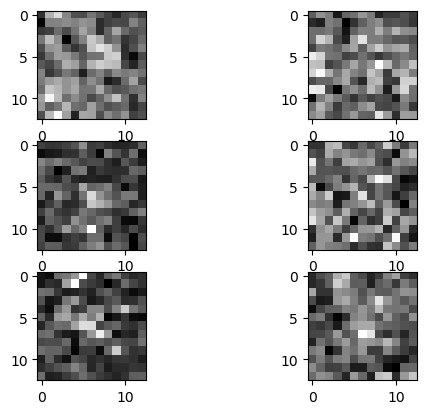

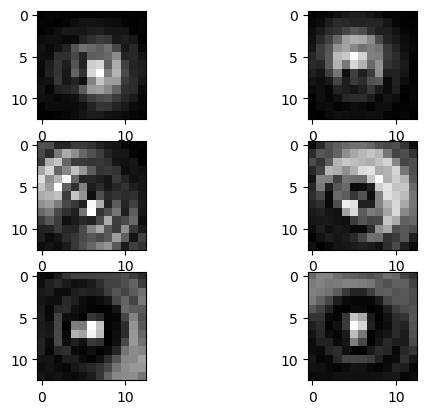

 51%|█████     | 51/100 [00:42<00:40,  1.22it/s]

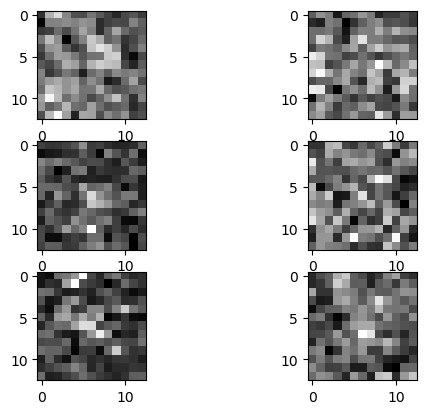

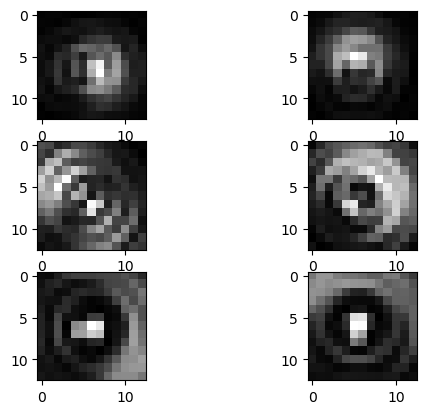

 52%|█████▏    | 52/100 [00:42<00:38,  1.25it/s]

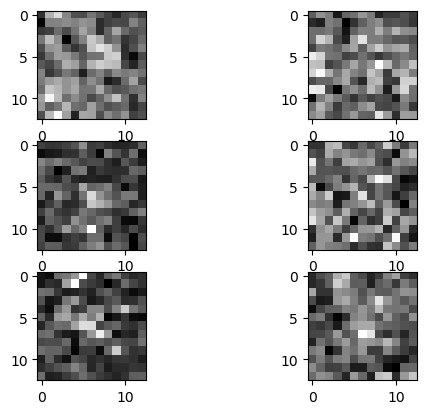

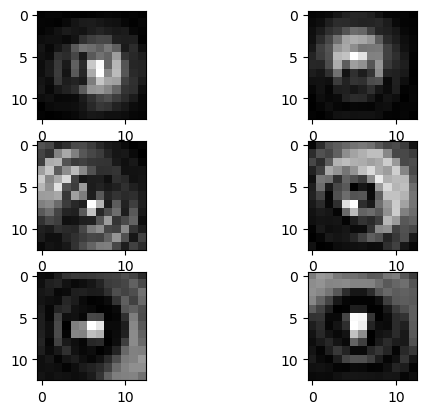

 53%|█████▎    | 53/100 [00:43<00:37,  1.25it/s]

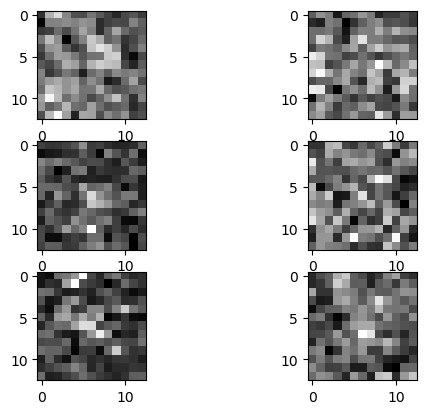

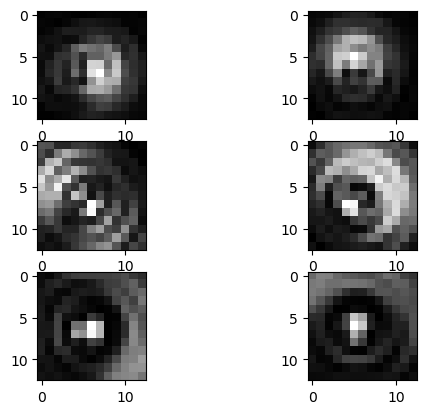

 54%|█████▍    | 54/100 [00:44<00:40,  1.14it/s]

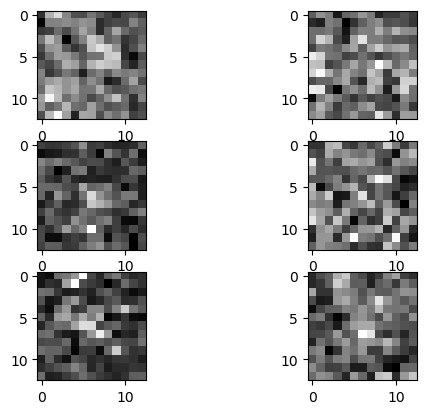

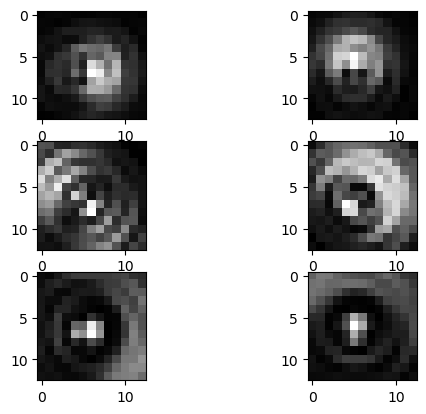

 55%|█████▌    | 55/100 [00:45<00:39,  1.14it/s]

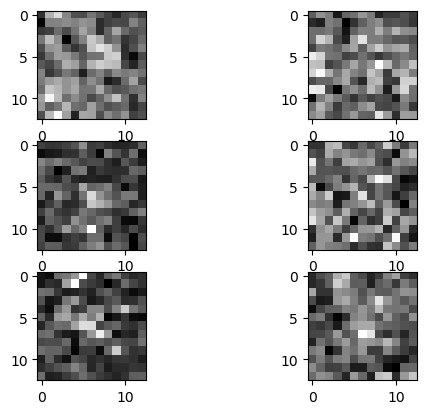

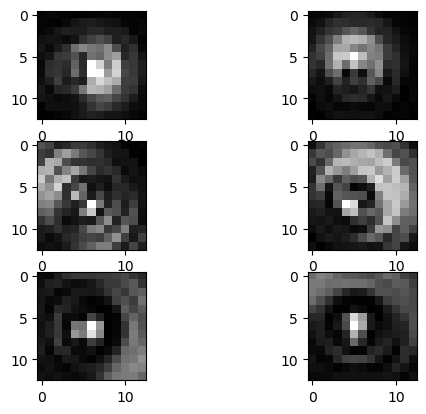

 56%|█████▌    | 56/100 [00:46<00:38,  1.15it/s]

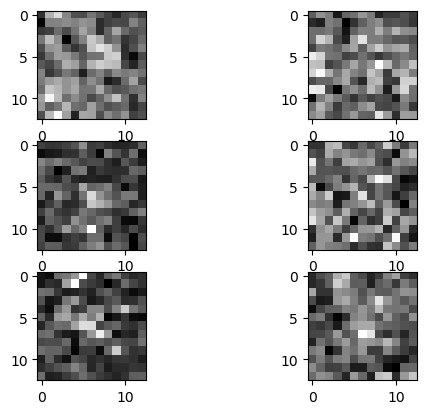

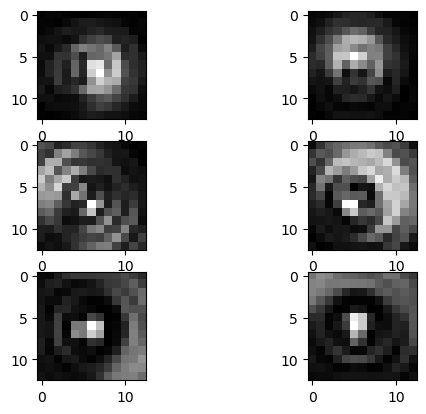

 57%|█████▋    | 57/100 [00:47<00:36,  1.17it/s]

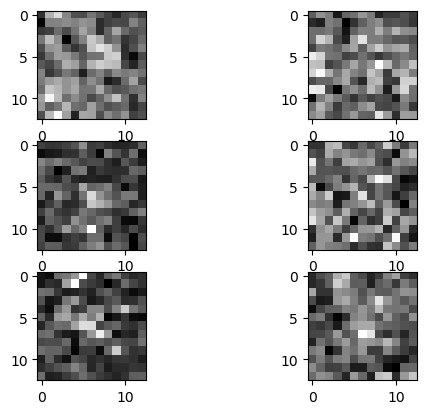

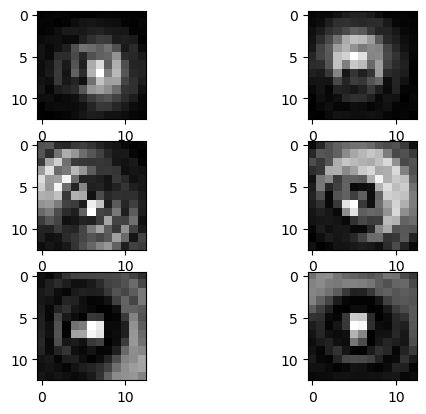

 58%|█████▊    | 58/100 [00:48<00:35,  1.17it/s]

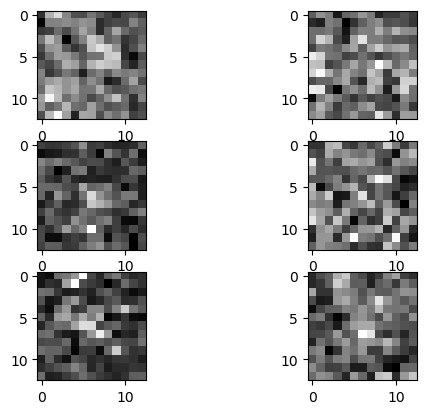

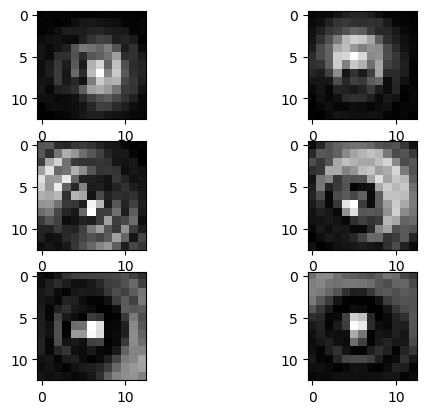

 59%|█████▉    | 59/100 [00:48<00:33,  1.21it/s]

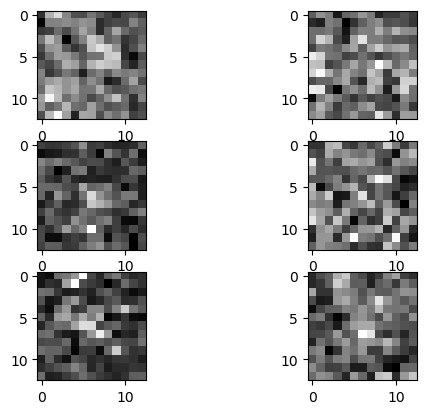

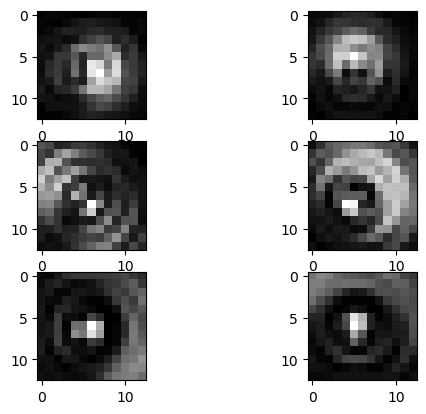

 60%|██████    | 60/100 [00:49<00:32,  1.25it/s]

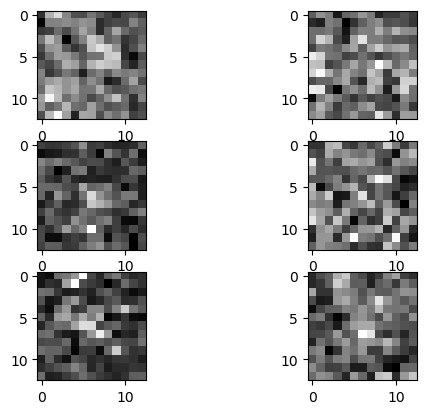

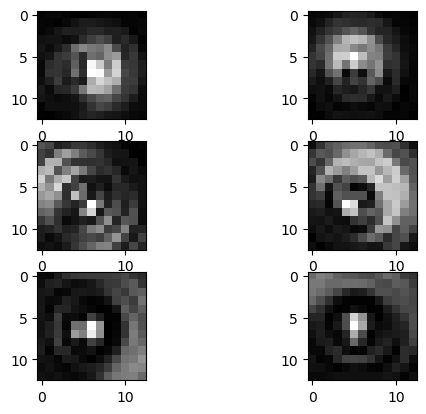

 61%|██████    | 61/100 [00:50<00:32,  1.19it/s]

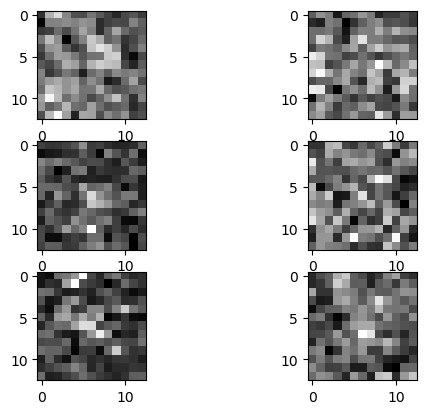

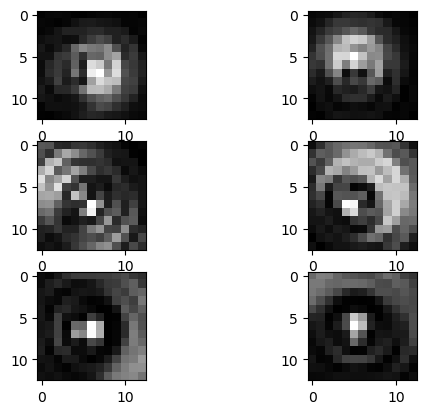

 62%|██████▏   | 62/100 [00:51<00:30,  1.23it/s]

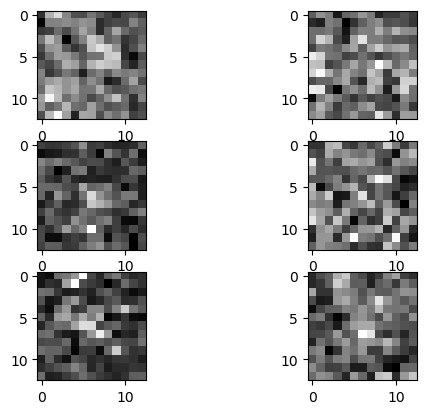

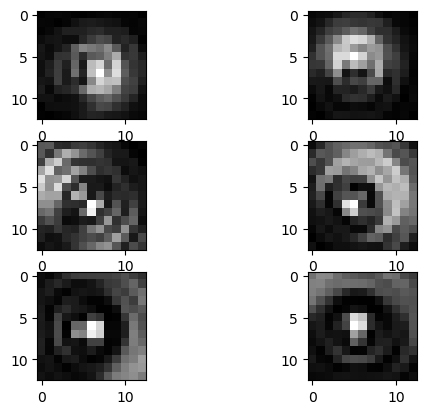

 63%|██████▎   | 63/100 [00:52<00:29,  1.25it/s]

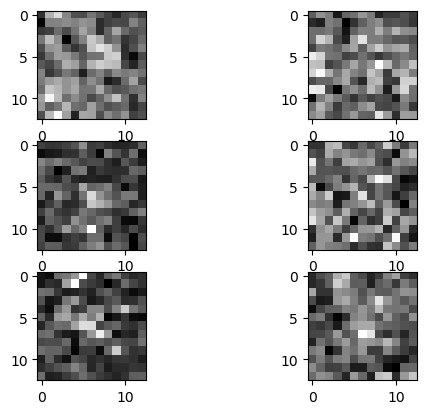

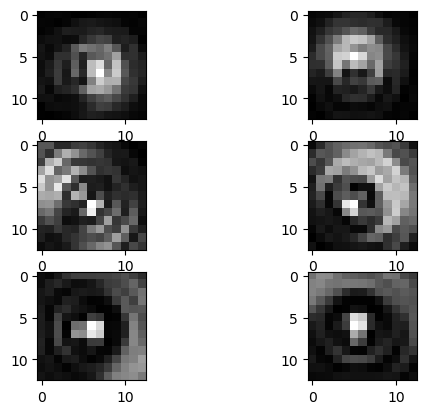

 64%|██████▍   | 64/100 [00:53<00:30,  1.19it/s]

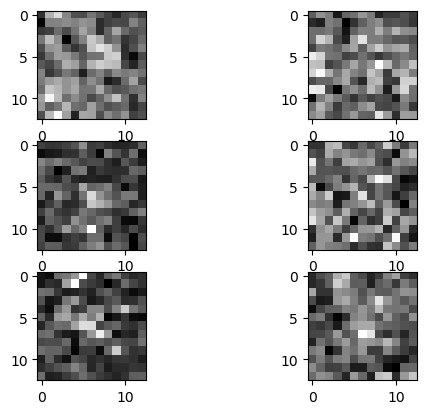

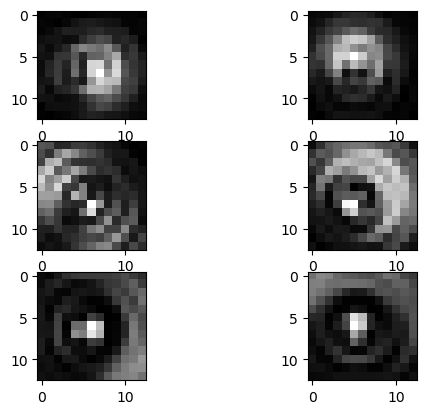

 65%|██████▌   | 65/100 [00:53<00:28,  1.22it/s]

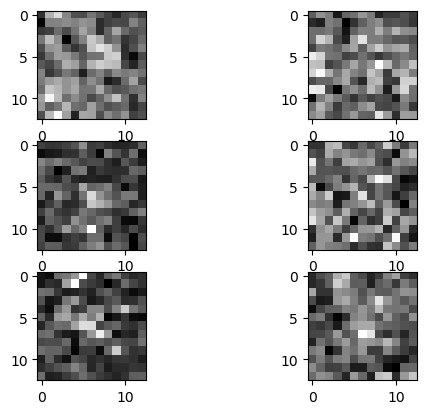

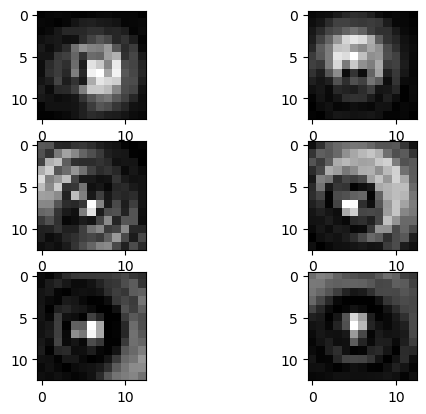

 66%|██████▌   | 66/100 [00:54<00:27,  1.25it/s]

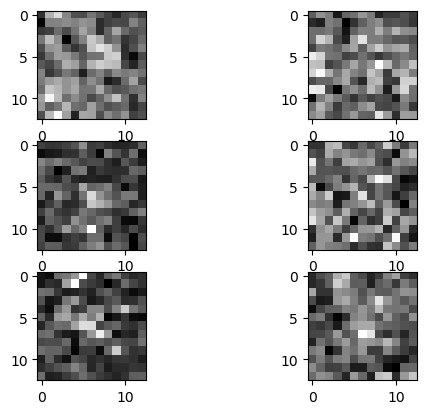

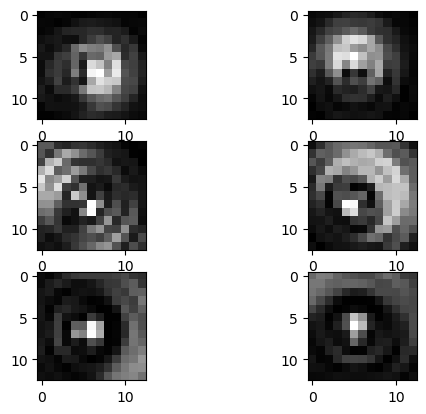

 67%|██████▋   | 67/100 [00:55<00:26,  1.27it/s]

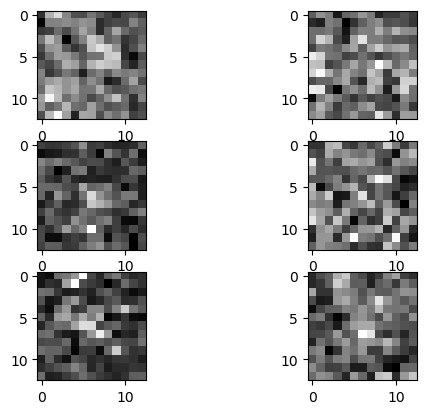

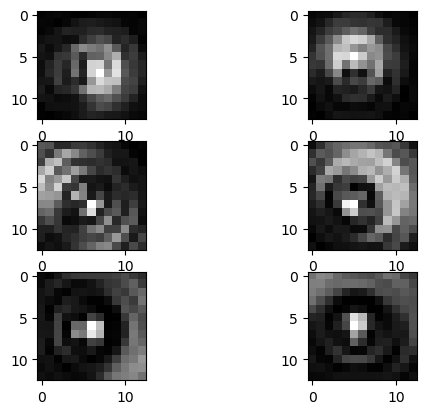

 68%|██████▊   | 68/100 [00:56<00:26,  1.20it/s]

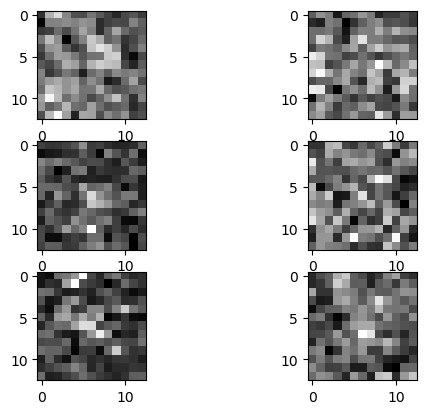

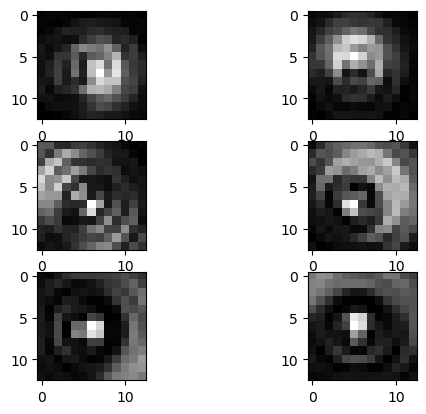

 69%|██████▉   | 69/100 [00:57<00:25,  1.24it/s]

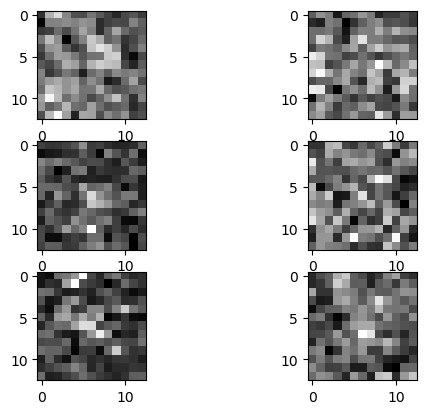

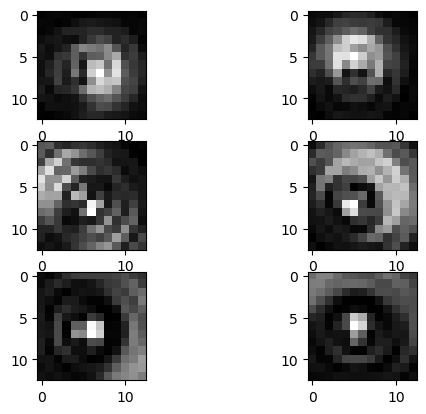

 70%|███████   | 70/100 [00:57<00:23,  1.26it/s]

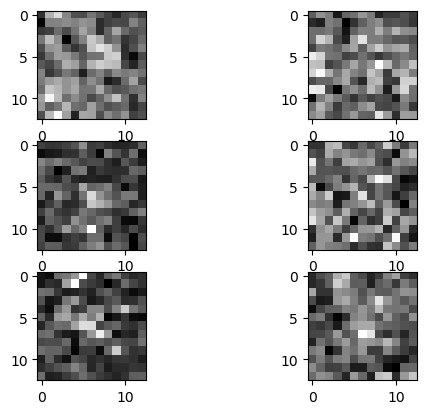

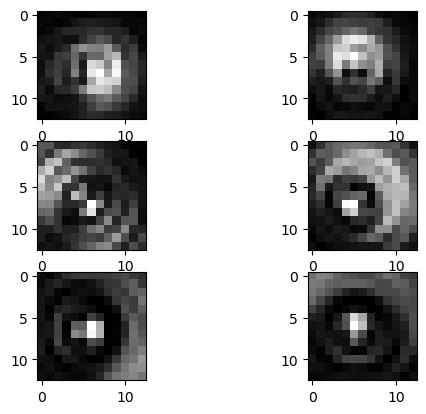

 71%|███████   | 71/100 [00:58<00:22,  1.27it/s]

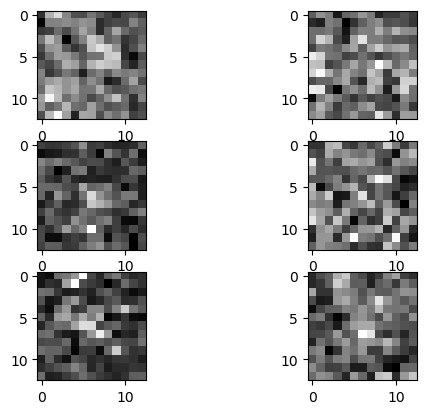

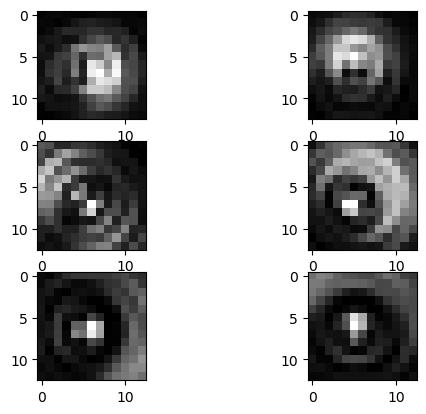

 72%|███████▏  | 72/100 [00:59<00:23,  1.20it/s]

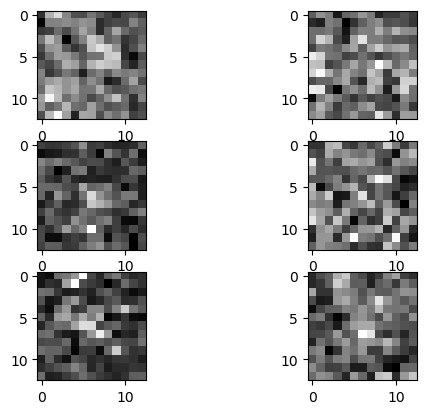

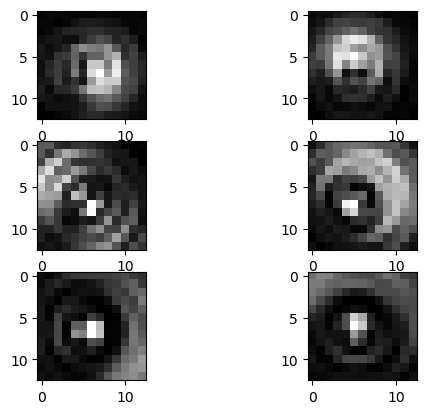

 73%|███████▎  | 73/100 [01:00<00:22,  1.19it/s]

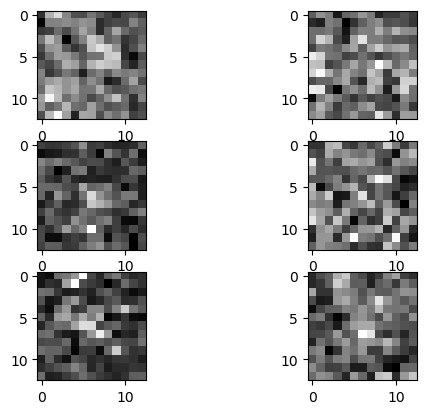

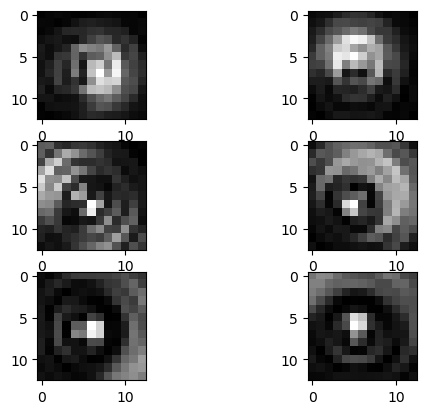

 74%|███████▍  | 74/100 [01:01<00:22,  1.17it/s]

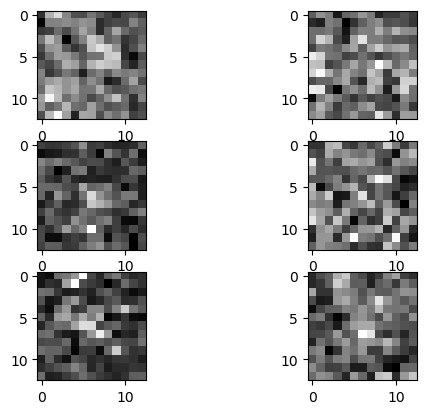

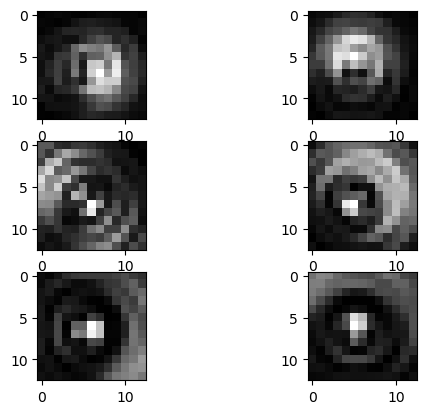

 75%|███████▌  | 75/100 [01:02<00:23,  1.08it/s]

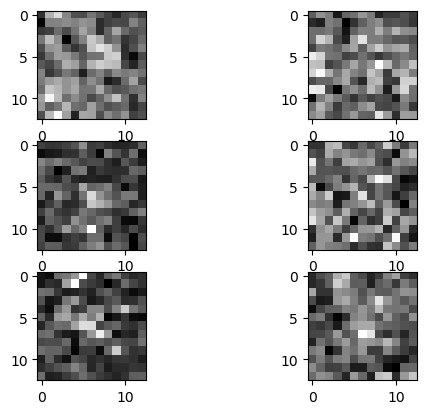

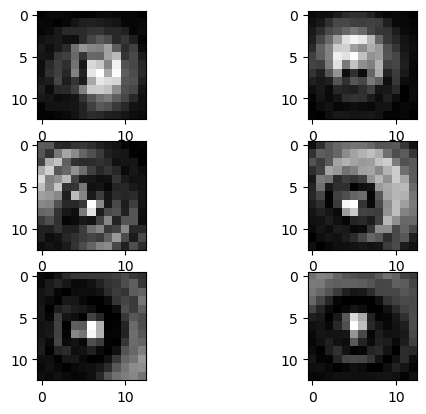

 76%|███████▌  | 76/100 [01:03<00:21,  1.11it/s]

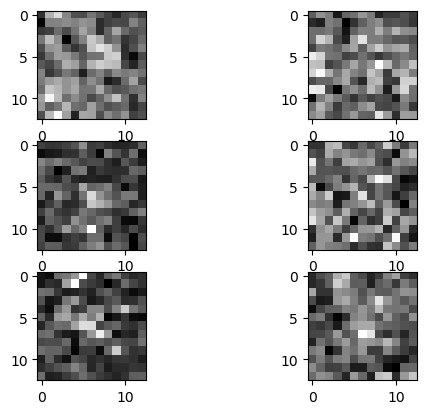

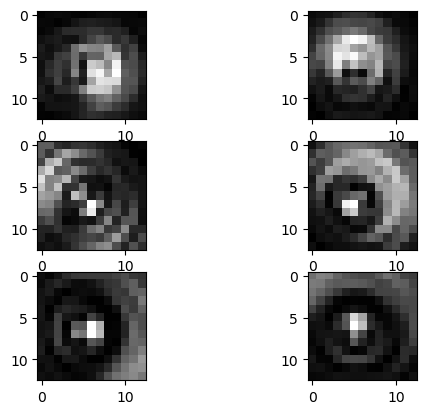

 77%|███████▋  | 77/100 [01:03<00:19,  1.16it/s]

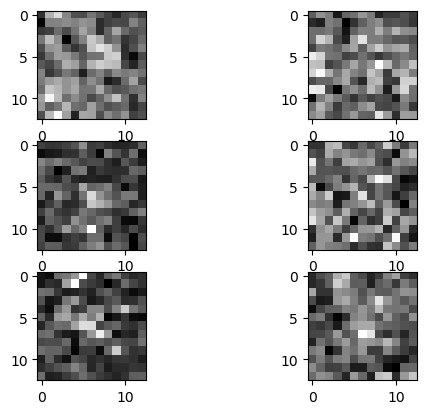

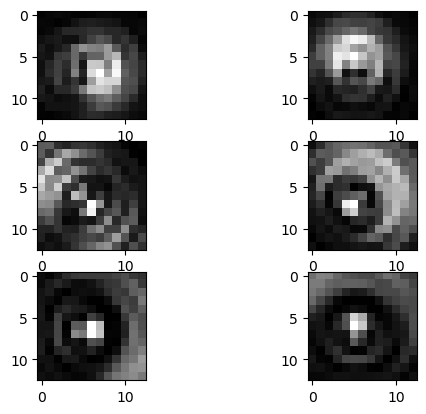

 78%|███████▊  | 78/100 [01:04<00:18,  1.19it/s]

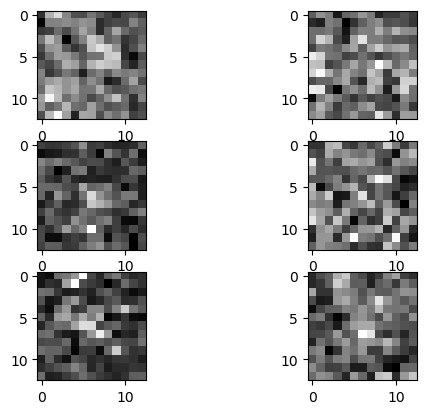

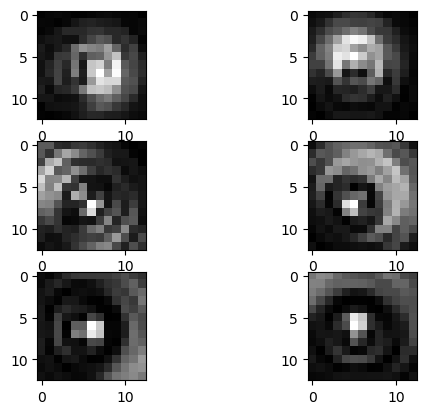

 79%|███████▉  | 79/100 [01:05<00:18,  1.16it/s]

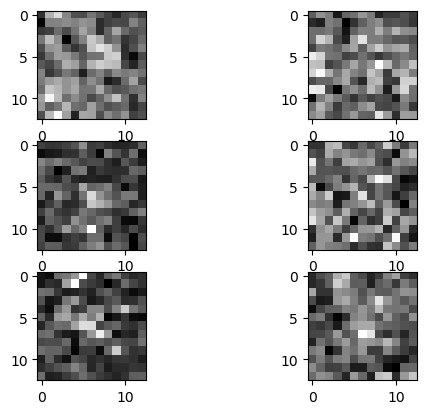

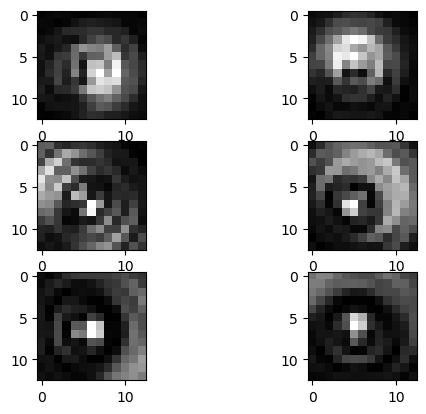

 80%|████████  | 80/100 [01:06<00:16,  1.19it/s]

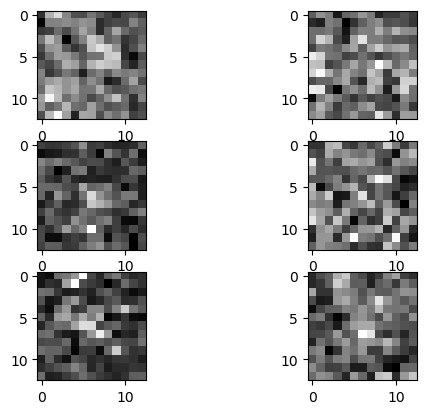

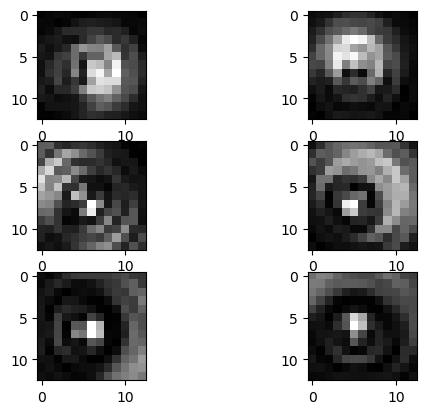

 81%|████████  | 81/100 [01:07<00:15,  1.22it/s]

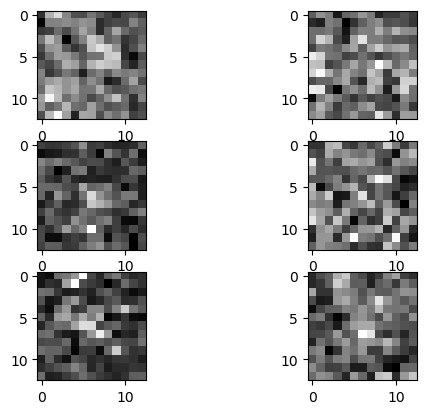

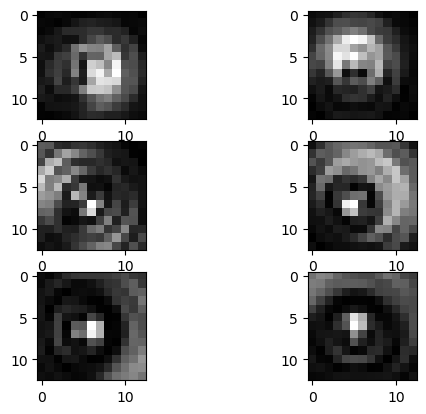

 82%|████████▏ | 82/100 [01:08<00:15,  1.16it/s]

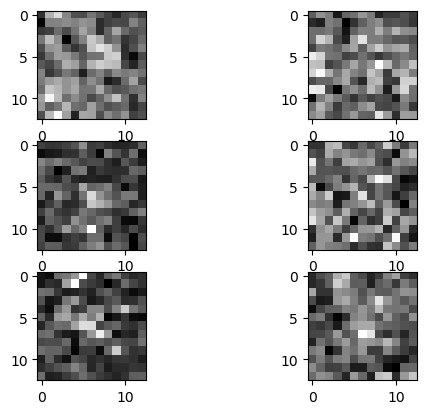

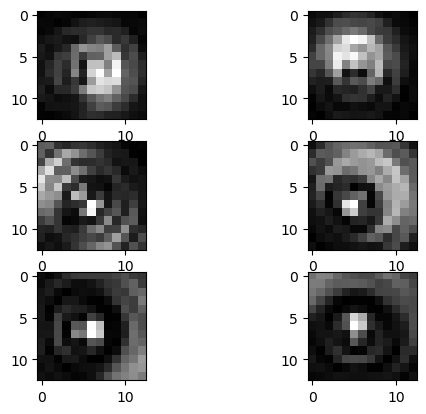

 83%|████████▎ | 83/100 [01:08<00:14,  1.20it/s]

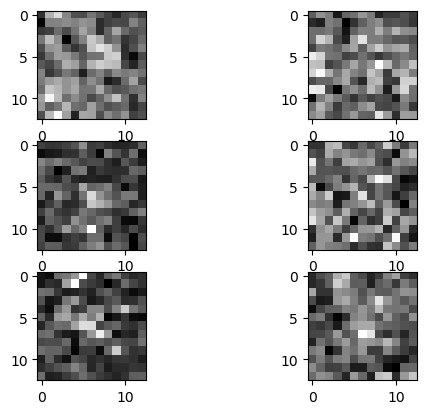

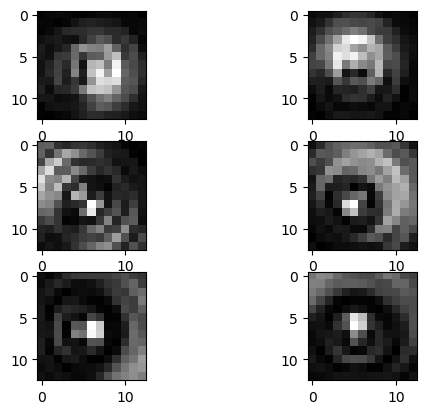

 84%|████████▍ | 84/100 [01:09<00:12,  1.24it/s]

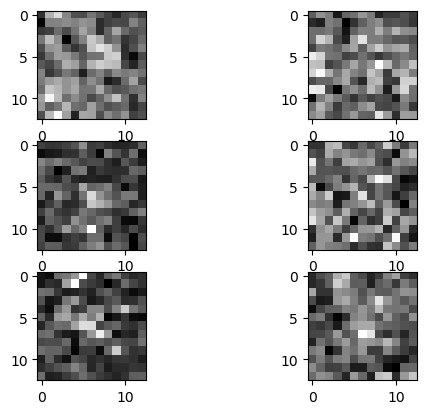

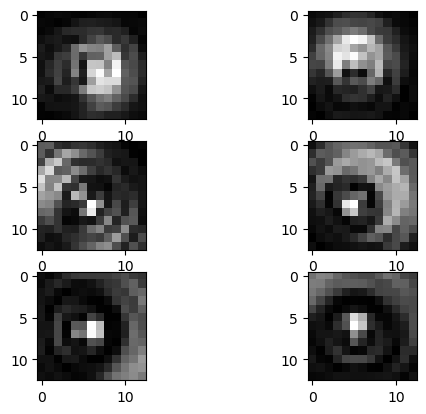

 85%|████████▌ | 85/100 [01:10<00:11,  1.26it/s]

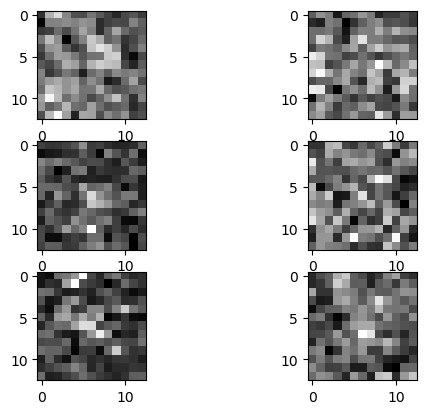

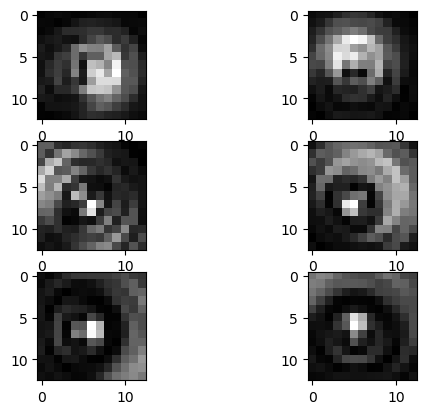

 86%|████████▌ | 86/100 [01:11<00:11,  1.19it/s]

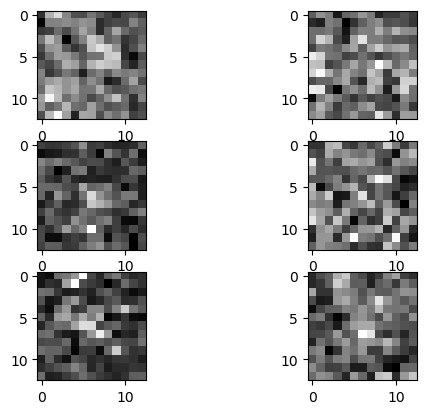

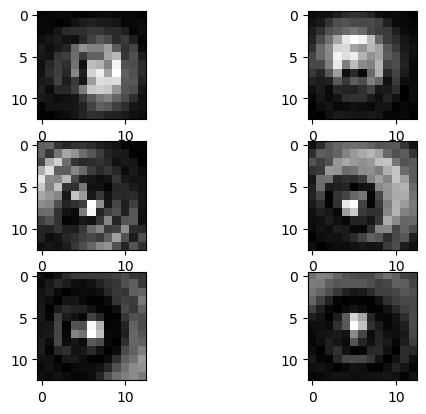

 87%|████████▋ | 87/100 [01:12<00:11,  1.18it/s]

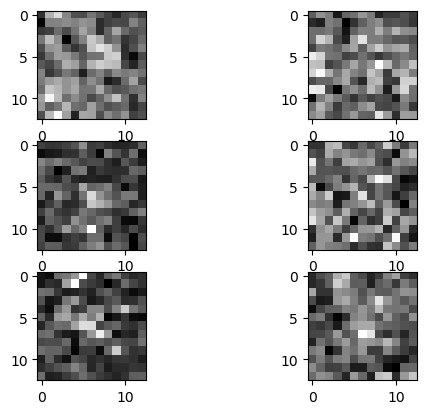

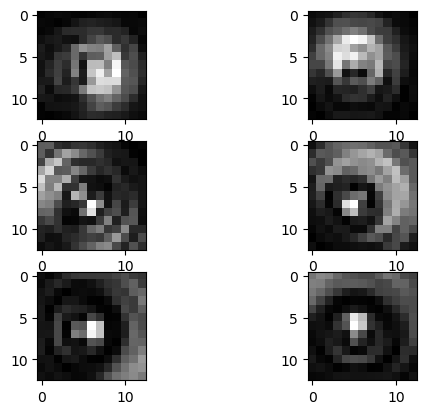

 88%|████████▊ | 88/100 [01:13<00:10,  1.18it/s]

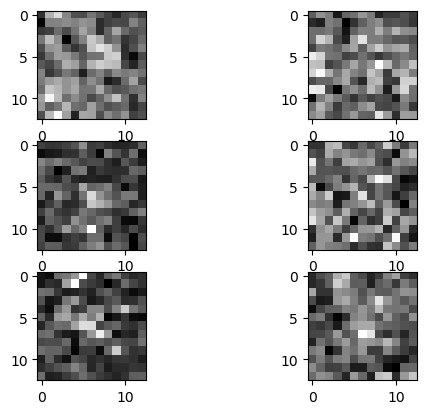

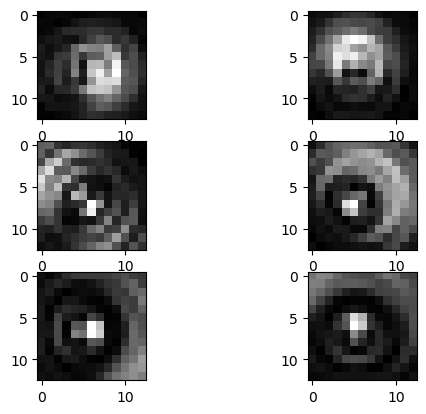

 89%|████████▉ | 89/100 [01:13<00:09,  1.17it/s]

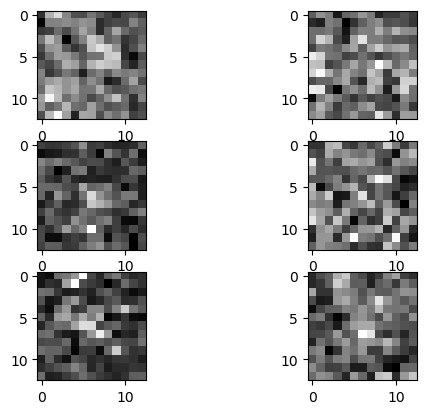

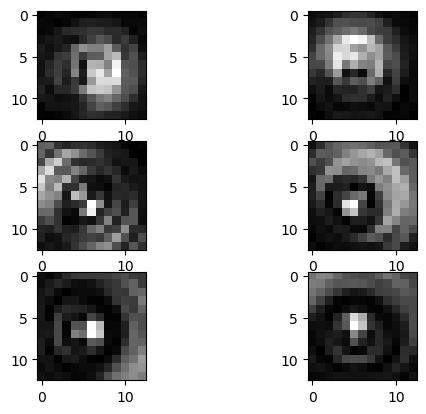

 90%|█████████ | 90/100 [01:14<00:08,  1.13it/s]

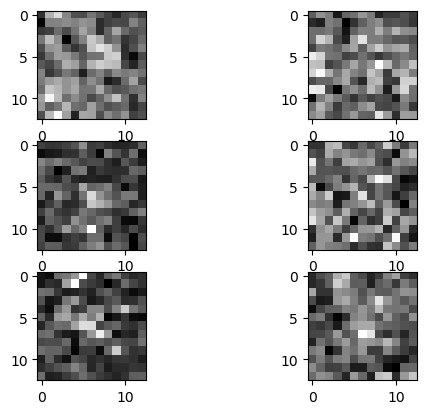

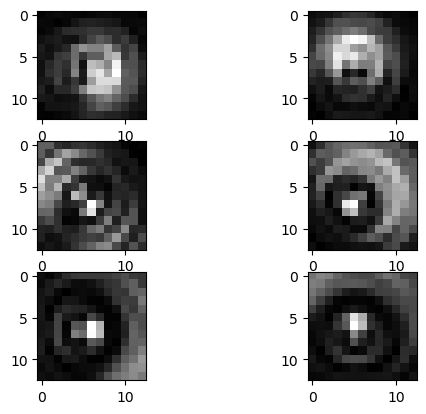

 91%|█████████ | 91/100 [01:15<00:07,  1.16it/s]

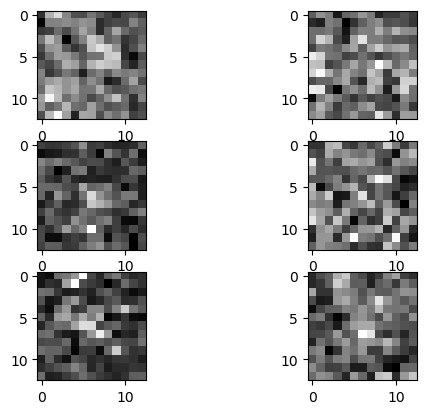

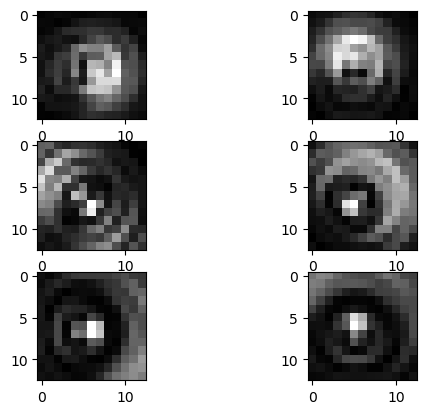

 92%|█████████▏| 92/100 [01:16<00:06,  1.17it/s]

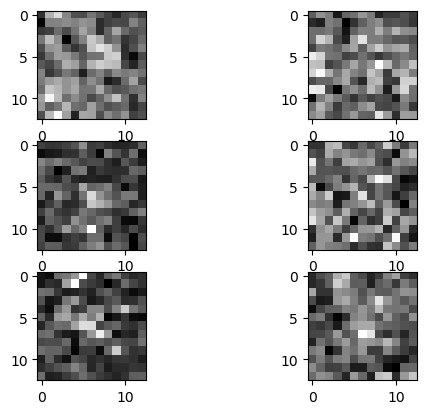

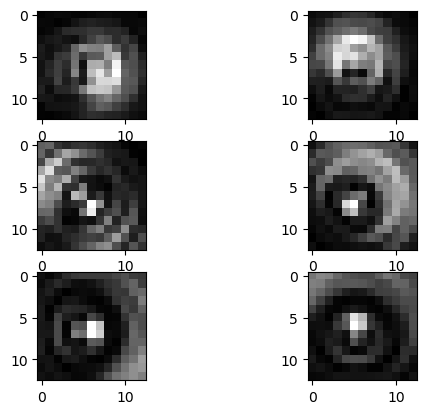

 93%|█████████▎| 93/100 [01:17<00:06,  1.09it/s]

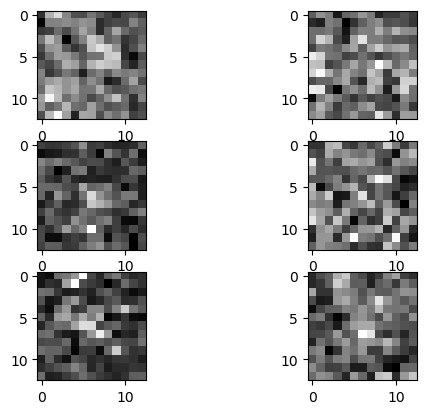

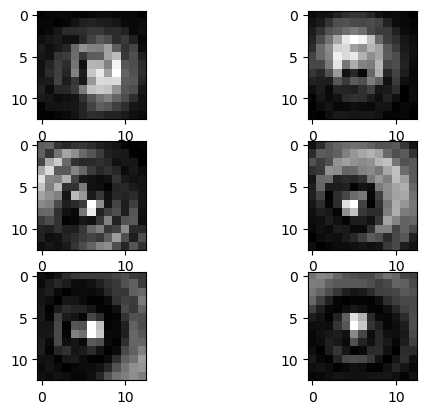

 94%|█████████▍| 94/100 [01:18<00:05,  1.11it/s]

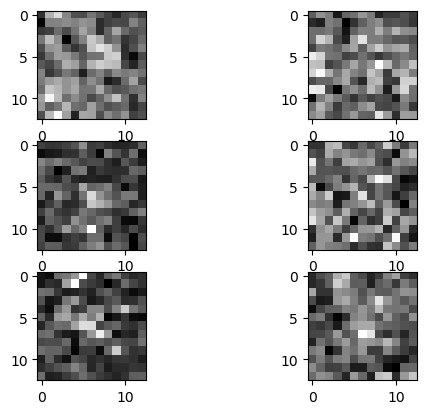

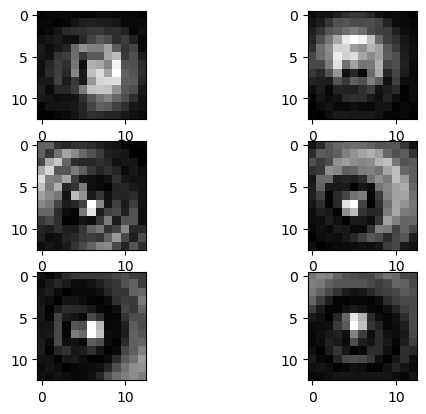

 95%|█████████▌| 95/100 [01:19<00:04,  1.14it/s]

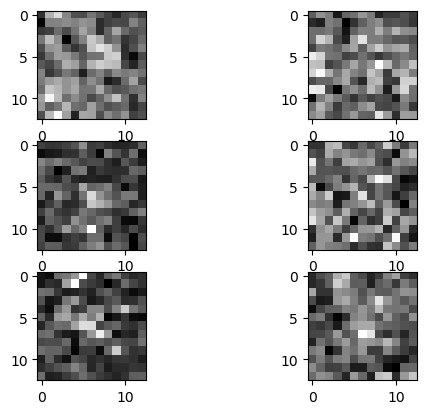

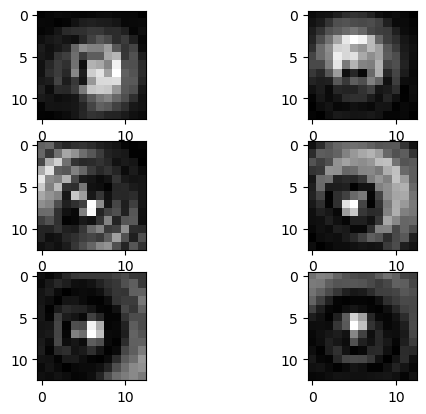

 96%|█████████▌| 96/100 [01:20<00:03,  1.19it/s]

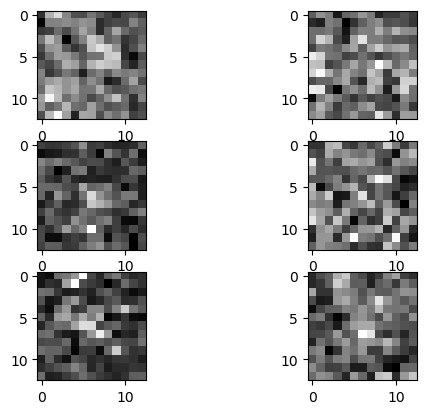

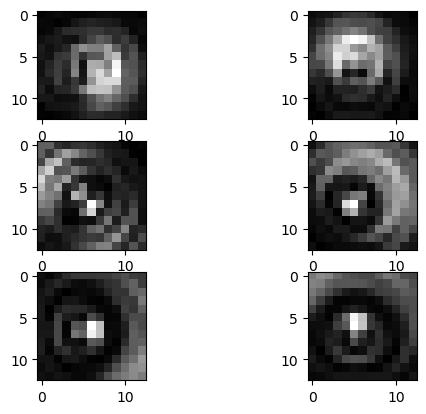

 97%|█████████▋| 97/100 [01:20<00:02,  1.19it/s]

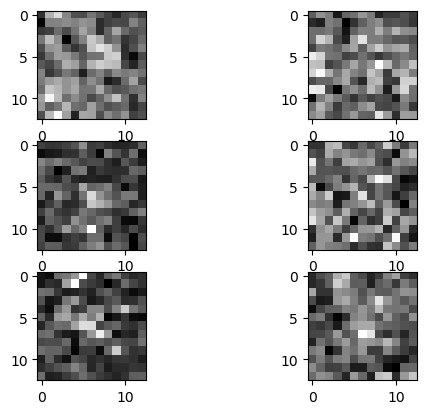

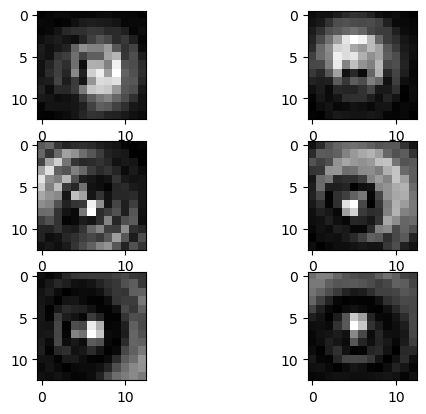

 98%|█████████▊| 98/100 [01:21<00:01,  1.22it/s]

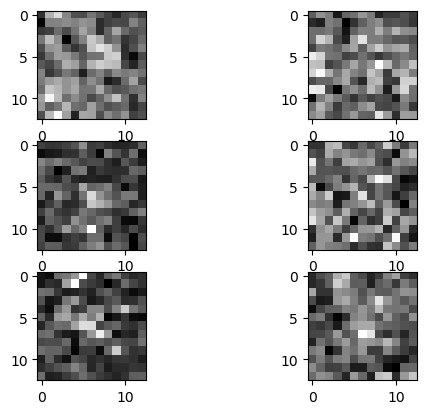

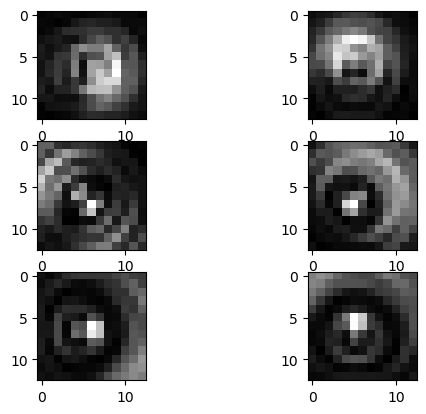

 99%|█████████▉| 99/100 [01:22<00:00,  1.26it/s]

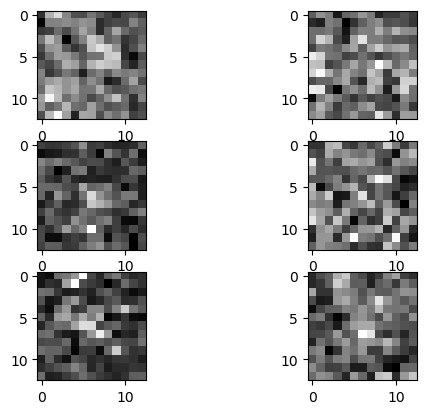

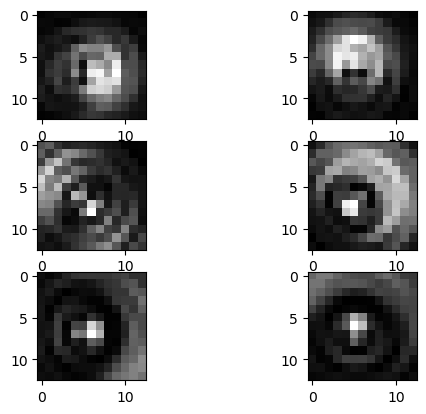

100%|██████████| 100/100 [01:23<00:00,  1.20it/s]


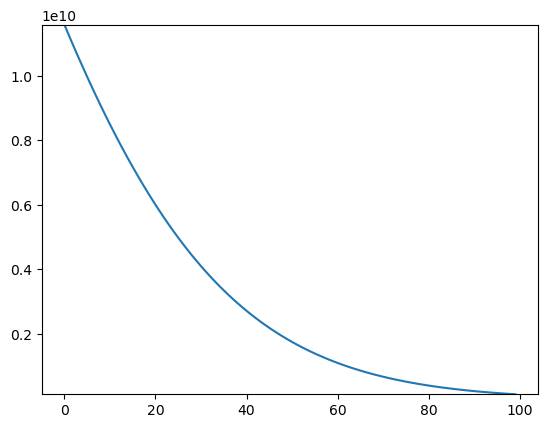

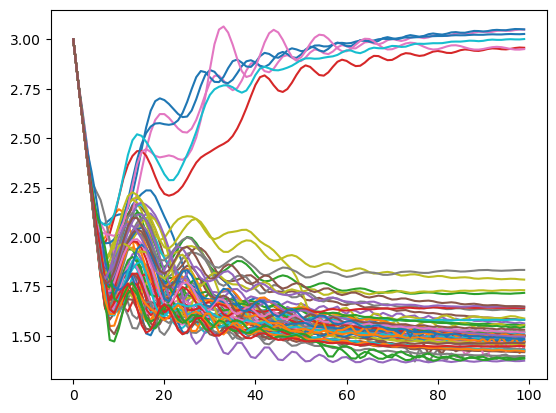

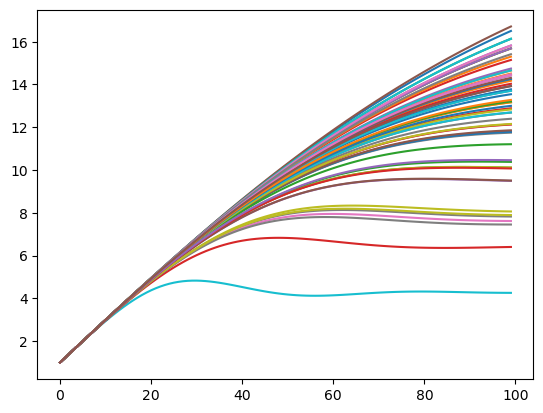

NPSF =  66


100%|██████████| 220/220 [02:36<00:00,  1.41it/s]


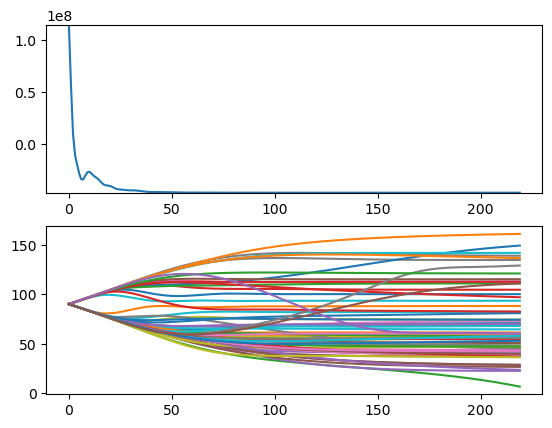

In [22]:
for batch_number in range(N_batch):
    t0 = time.time()
    raw, error_indices = extract_frames((batch_number+batch_offset)*Nframe+1, Nframe)
    x, y, z, rho, delta, index_frame = extract_positions((batch_number+batch_offset)*Nframe+1, Nframe, error_indices)
    raw = raw*sensitivity/(QE*EM)

    sigma = np.std(raw.flatten())
    background = np.mean(raw.flatten())

    nb = len(x)
    for k, ele in enumerate(x):
        if np.isnan(x[nb-1-k]) or np.isnan(y[nb-1-k]) or np.isnan(z[nb-1-k]) or np.isnan(rho[nb-1-k]) or np.isnan(delta[nb-1-k]):
            x = np.delete(x,nb-1-k,0)
            y = np.delete(y,nb-1-k,0)
            z = np.delete(z,nb-1-k,0)
            rho = np.delete(rho,nb-1-k,0)
            delta = np.delete(delta,nb-1-k,0)
            index_frame = np.delete(index_frame,nb-1-k,0)
    
    NPSF = len(x)

    single_psf = extract_raw_xy(raw[0], x[index_frame==0], y[index_frame==0])
    for i in range(1,Nframe):
        single_psf = np.concatenate((single_psf, extract_raw_xy(raw[i], x[index_frame==i], y[index_frame==i])))

    single_psf = single_psf[:,::-1]

    x_start = torch.tensor([0. for k in range(len(x))], requires_grad=False, device=device)
    y_start = torch.tensor([0. for k in range(len(x))], requires_grad=False, device=device)

    z_exp =  torch.tensor([3. for k in range(len(x))], requires_grad=False, device=device) 

    rho_exp = torch.tensor(rho, requires_grad=False, device=device)
    delta_exp = torch.tensor(delta, requires_grad=False, device=device)

    d_ = -torch.tensor([d[1] for k in range(len(x))], requires_grad=False, device=device)
    second_plane = torch.tensor([d[1]-d[0], 0, d[1]-d[2]])
    polar_projections = torch.tensor(np.array([0, 45, 0]))

    N=torch.tensor(80, device=device)
    l_pixel=torch.tensor(16, device=device)
    NA=torch.tensor(1.4, device=device)
    mag=torch.tensor(100, device=device)
    lambd=torch.tensor(638, device=device)
    f_tube=torch.tensor(200, device=device)
    MAG=torch.tensor(200/150, device=device)
    xx, yy, th1, phi, [Ex0, Ex1, Ex2], [Ey0, Ey1, Ey2], r, r_cut, k_, f_o = vectorial_BFP_perfect_focus(N, NA=NA, mag=mag, lambd=lambd, f_tube=f_tube, device=device)

    if batch_number==0:
        phase_mask = torch.stack([torch.ones((N,N), device=device), torch.ones((N,N), device=device), torch.ones((N,N), device=device)])
        zernike_base = generate_zernike_base(r_cut=r_cut, N=N, zernike_order=4, device=device)
        zernike_coefs_x = torch.zeros((3,15), device=device)
        zernike_coefs_y = torch.zeros((3,15), device=device)
    
    noisy_psf = torch.tensor([single_psf[k] for k in range(len(x))], device=device)

    u, v, M = compute_M(xp=x_start, yp=y_start, zp=z_exp, d=d_, x=xx, y=yy, th1=th1, phi=phi, Ex0=Ex0, Ex1=Ex1, Ex2=Ex2
                    , Ey0=Ey0, Ey1=Ey1, Ey2=Ey2, r=r, r_cut=r_cut, k=k_, f_o=f_o, phase_maskx=phase_mask, phase_masky=phase_mask, zernike_base=zernike_base, zernike_coefs_x=zernike_coefs_x, zernike_coefs_y=zernike_coefs_x,
                        second_plane=second_plane, polar_projections=polar_projections, N=N, l_pixel=l_pixel
                    , NA=NA, mag=mag, lambd=lambd, f_tube=f_tube, MAG=MAG, device=device, polar_offset=0., polar_offset2=0.)
    h = PSF(rho=torch.tensor(np.array([45. for k in range(NPSF)]), device=device), eta=torch.tensor([45. for k in range(NPSF)], device=device), delta=torch.tensor([100. for k in range(NPSF)], device=device), M=M, N_photons=torch.tensor([1000. for k in range(NPSF)], device=device))
    dim_simu = int(h.shape[-1]//2)
    psftest = h[:,:,:,dim_simu-10:dim_simu+10+1,dim_simu-10:dim_simu+10+1]
    fig, ax = plt.subplots(3,2)
    for aa in range(3):
        for bb in range(2):
            ax[aa,bb].imshow(psftest[1,aa,bb].detach().cpu().numpy(), cmap='gray')
    plt.show()

    ### first SGD on pos
    Nstart = torch.tensor([1000 for i in range(NPSF)], requires_grad=False, device=device)
    eta_rd = torch.tensor([45. for k in range(NPSF)], requires_grad=False, device=device)
    delta_rd = torch.tensor([150. for k in range(NPSF)], requires_grad=False, device=device)

    params = torch.cat((x_start, y_start, z_exp, Nstart/1000))
    params.requires_grad=True

    optimizer = torch.optim.Adam([params], lr=0.2)  # Learning rate = 0.012

    num_epochs_max = 100
    loss_ = []
    z__ = []
    N__ = []
    for i in tqdm(range(num_epochs_max)):
        optimizer.zero_grad()  # Reset gradients
        loss = loss_pos(params[0:NPSF], params[NPSF:2*NPSF], params[2*NPSF:3*NPSF], rho_exp
                            , eta_rd, delta_exp, params[3*NPSF:4*NPSF]*1000, noisy_psf, second_plane, background, sigma, dim_simu, plot=True)#(i==num_epochs_max-1)) 
        loss_.append(loss.cpu().detach().numpy())
        z__.append(params[2*NPSF:3*NPSF].cpu().detach().numpy())
        N__.append(params[3*NPSF:4*NPSF].cpu().detach().numpy())
        loss.backward()  # Backpropagation
        optimizer.step()  # Update parameters
    ax = plt.plot(loss_)
    plt.ylim((np.min(np.array(loss_)), np.max(np.array(loss_))))
    plt.show()
    ax = plt.plot(z__)
    plt.show()
    ax = plt.plot(N__)
    plt.show()
    del(ax, loss_, z__, N__)

    x_found = params[0:NPSF].detach()
    y_found = params[NPSF:2*NPSF].detach()
    z_found = params[2*NPSF:3*NPSF].detach()
    N_found = params[3*NPSF:4*NPSF].detach()*1000
    del(params, loss)
    print('NPSF = ', NPSF)

    ### SGD 2 on orientation

    u, v, M = compute_M(xp=x_found, yp=y_found, zp=z_found, d=d_, x=xx, y=yy, th1=th1, phi=phi, Ex0=Ex0, Ex1=Ex1, Ex2=Ex2
                    , Ey0=Ey0, Ey1=Ey1, Ey2=Ey2, r=r, r_cut=r_cut, k=k_, f_o=f_o, phase_maskx=phase_mask, phase_masky=phase_mask, zernike_base=zernike_base, zernike_coefs_x=zernike_coefs_x, zernike_coefs_y=zernike_coefs_x,
                        second_plane=second_plane, polar_projections=polar_projections, N=N, l_pixel=l_pixel
                    , NA=NA, mag=mag, lambd=lambd, f_tube=f_tube, MAG=MAG, device=device, polar_offset=20., polar_offset2=20.)
    
    eta_rd = torch.tensor([90. for k in range(NPSF)], requires_grad=False, device=device)
    offset_proj=27.
    #params = torch.cat((rho_exp, eta_rd, delta_exp, N_found/1000))
    #params = torch.cat((eta_rd, eta_rd, eta_rd, N_found/1000))
    params = torch.cat((eta_rd, eta_rd, eta_rd, N_found/1000))
    params.requires_grad=True

    # Use Stochastic Gradient Descent (SGD) to optimize params
    optimizer = torch.optim.Adam([params], lr=0.7)  # Learning rate = 0.01

    num_epochs_max = 220
    loss_ = []
    eta_ = []
    pol=[]
    for i in tqdm(range(num_epochs_max)):
        optimizer.zero_grad()  # Reset gradients
        #loss = loss_angle(M.detach(), params[:NPSF], params[1*NPSF:2*NPSF], params[2*NPSF:3*NPSF], 1000*params[3*NPSF:4*NPSF], noisy_psf, background, sigma, dim_simu)
        loss = loss_angle_with_M(offset_proj, offset_proj, params[:NPSF], params[1*NPSF:2*NPSF], params[2*NPSF:3*NPSF], 1000*params[3*NPSF:4*NPSF], noisy_psf, background, sigma, dim_simu)
        loss_.append(loss.cpu().detach().numpy())
        eta_.append(params[1*NPSF:2*NPSF].cpu().detach().numpy())
        #pol.append(params[-2:].cpu().detach().numpy())
        loss.backward()  # Backpropagation
        optimizer.step()  # Update parameters
    fig, ax = plt.subplots(2)
    ax[0].plot(loss_) 
    ax[0].set_ylim((np.min(np.array(loss_)), np.max(np.array(loss_))))
    ax[1].plot(eta_)
    plt.show()
    del(fig, ax)

    rho_found=params[0:NPSF].detach()%180
    eta_found=params[1*NPSF:2*NPSF].detach()%180
    delta_found=params[2*NPSF:3*NPSF].detach()
    N_found2 = 1000*params[3*NPSF:4*NPSF].detach()
    offset_proj_found = torch.tensor(27.)
    offset_proj_found2 = torch.tensor(offset_proj)
    del(params, loss, eta_, loss_)
    u, v, M = compute_M(xp=x_found, yp=y_found, zp=z_found, d=d_, x=xx, y=yy, th1=th1, phi=phi, Ex0=Ex0, Ex1=Ex1, Ex2=Ex2
                    , Ey0=Ey0, Ey1=Ey1, Ey2=Ey2, r=r, r_cut=r_cut, k=k_, f_o=f_o, phase_maskx=phase_mask, phase_masky=phase_mask, zernike_base=zernike_base, zernike_coefs_x=zernike_coefs_x, zernike_coefs_y=zernike_coefs_x,
                        second_plane=second_plane, polar_projections=polar_projections, N=N, l_pixel=l_pixel
                    , NA=NA, mag=mag, lambd=lambd, f_tube=f_tube, MAG=MAG, device=device, polar_offset=offset_proj_found, polar_offset2=offset_proj_found2)
    score = score_eval(M.detach().cpu(), rho_found.cpu(), eta_found.cpu(), delta_found.cpu(), N_found2.cpu(), noisy_psf.cpu(), background, sigma, dim_simu)
    x_ = (x/0.120).astype(int)*0.12 + x_found.cpu().detach().numpy()
    y_ = (y/0.120).astype(int)*0.12 + y_found.cpu().detach().numpy()
    np.savez_compressed('D:/AMAURY/experimental_processed/these_4polar_MFM/anneLise2/'+str(int(batch_number)+1+batch_offset)+'.npz', frame = index_frame, x=x_, y=y_, z=1000*z_found.cpu().detach().numpy(), N_photons=N_found2.cpu().detach().numpy(), offset_proj=offset_proj_found.cpu().detach().numpy(), offset_proj2=offset_proj_found2.cpu().detach().numpy(), rho=rho_found.cpu().detach().numpy(), eta=eta_found.cpu().detach().numpy(), delta=delta_found.cpu().detach().numpy(), score=score, x_start=x, y_start=y, z_start=z, rho_start=rho, delta_start=delta)
